# Main Report

## [Tidy Tuesday Spotify Dataset](https://github.com/rfordatascience/tidytuesday/tree/main/data/2020/2020-01-21)

Author: [Ashley Kennedy](ashley.g.kennedy@gmail.com)

## Introduction

For this project, I utilized the [Spotify](https://github.com/rfordatascience/tidytuesday/tree/main/data/2020/2020-01-21) dataset from the TidyTuesday Github Repository. I cleaned and transformed the data (date conversions and tackling skew) and then used regression to see if we are able to predict the transformed `track_popularity` score. My end goal was to identify which audio features best explain `track_popularity`.

### Major Findings

My target variable was the logit transformed popularity variable, `y` to make modeling more suitable due to the high skew of `track_popularity` with many values near 0. This also impacted many audio features which also tended to have extreme right skews, so I applied the appropriate transformations (log, logit, square root) to those variables for the modeling process.

There appeared to be very weak relationships between the continuous input variables and `y` shown by the correlation heatmap. The variables `loudness` and `energy` were the most correlated (~0.68) indicating a potential audio feature cluster, but not necessarily predictive of popularity.

### High Influence Inputs

My models indicated that `energy`, `danceability`, and `playlist_genre` tend to influence the outcome the most as they showed to have larger coefficient magnitudes than other input variables in many of the models, meaning that they have a stronger association with the transformed popularity outcome `y`.

### EDA Trends and Relationships

Exploratory data analysis was very useful in identifying trends and relationships across features. EDA revealed which audio features move together through correlation heatmaps and pairplots. Grouped relationships and faceted plots demonstrated whether relationships are consistent across different groups and subpopulations. Cross-tabulation plots also aided in cluster analysis to support the conclusions drawn.

### Cluster Consistency with Predictive Models

For cluster analysis, I decided to use PCA due to the high dimension of the data. I created a cumulative explained variance plot to visualize how many components most closely aligns with 75% of the variance in the data, which ended up being 6. I then clustered using KMeans and Ward Hierarchy. The knee-bend plot created for KMeans is ambiguous, but suggests 4-6 clusters as reasonable while ward hierarchy suggested 4 clusters. The clusters produced demonstrated audio-similarity groups, but unfortunately did not align with any of the categorical variables in the data and was not consistent with any of the conclusions drawn from the predictive models.

### Conclusions

My conclusions are supported by multiple pieces of evidence, not just predictive modeling. Exploratory data analysis provided the initial essential evidence in correlations, scatterplots, PCA, and faceted summaries to help reveal which audio features show consistent relationships with popularity. Predictive models provided quantitative effect sizes and significance, while regression diagnostics tested whether those estimates were reliable. Cross-tabulations measured how well audio-based clusters aligned with different categorical variables

### Skills Learned

Working through this project reinforced several practical lessons as well as push me to learn new skills that I will carry forward. I became more diciplined in early-stage checks, validating inputs before aggregation, and handling transformations. I have learned that EDA is not only a visual guide, but a crucial step in the modeling process.

On the modeling side, I strengthened my use of standard preprocessing and model-validation. I learned new techniques such as creating the cumulative variance plot to help decide how many principal components I want to use.

## EDA

### Import Modules

Before performing EDA, I will import the required modules.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Basic EDA Information

#### Load Data

I will be using the Spotify dataset from Tidy Tuesday Github repo.

In [2]:
songs_url = 'https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-01-21/spotify_songs.csv'

In [3]:
spotify = pd.read_csv(songs_url)

In [4]:
spotify.shape

(32833, 23)

There are 32,833 rows and 23 columns in the dataset.

The names and data types of the variables are listed below.

In [5]:
spotify.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  object 
 1   track_name                32828 non-null  object 
 2   track_artist              32828 non-null  object 
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  object 
 5   track_album_name          32828 non-null  object 
 6   track_album_release_date  32833 non-null  object 
 7   playlist_name             32833 non-null  object 
 8   playlist_id               32833 non-null  object 
 9   playlist_genre            32833 non-null  object 
 10  playlist_subgenre         32833 non-null  object 
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudne

In [6]:
spotify.isna().sum()[ spotify.isna().sum() > 0 ]

track_name          5
track_artist        5
track_album_name    5
dtype: int64

The following variables `track_name`, `track_artist`, and `track_album_name` all contain 5 missing values.

Below demonstrates the number of unique values for each variable. As we can see, `key` and `mode` are both integer but I will be treating them as categorical variables for their low count of unique variables.

In [7]:
spotify.nunique()

track_id                    28356
track_name                  23449
track_artist                10692
track_popularity              101
track_album_id              22545
track_album_name            19743
track_album_release_date     4530
playlist_name                 449
playlist_id                   471
playlist_genre                  6
playlist_subgenre              24
danceability                  822
energy                        952
key                            12
loudness                    10222
mode                            2
speechiness                  1270
acousticness                 3731
instrumentalness             4729
liveness                     1624
valence                      1362
tempo                       17684
duration_ms                 19785
dtype: int64

### Clean the Data

Before I move on to creating visualizations, I will clean the data.

I will begin by removing the identifier columns that will not be used.

In [8]:
spotify_copy = spotify.dropna().copy()

The column `track_album_release_date` has an `object` data type. However, I will change this to have a `datetime` data type and add additional columns to represent the release year and release month of a song.

In [9]:
spotify_copy['track_album_release_date'] = pd.to_datetime(spotify_copy.track_album_release_date, format='mixed')

In [10]:
spotify_copy['release_month'] = spotify_copy.track_album_release_date.dt.month

spotify_copy['release_year'] = spotify_copy.track_album_release_date.dt.year

In [11]:
spotify_copy.loc[ :, ['track_album_release_date', 'release_month', 'release_year'] ].head()

,track_album_release_date,release_month,release_year
0,2019-06-14,6,2019
1,2019-12-13,12,2019
2,2019-07-05,7,2019
3,2019-07-19,7,2019
4,2019-03-05,3,2019


I will also change `release_month` to be a categorical variable, as well as convert `release_year` into a binary variable with values "recent" and "older" based on if the `release_year` is less than 2010.

In [12]:
spotify_copy['release_month'] = spotify_copy.release_month.astype('category')

In [13]:
spotify_copy['bin_year'] = np.where( spotify_copy.release_year < 2010, 'older', 'recent')

In [14]:
spotify_copy.groupby(['track_id', 'track_album_id', 'playlist_id']).size().reset_index(name='num_rows').\
num_rows.value_counts()

num_rows
1    31714
2      482
3       50
Name: count, dtype: int64

We can see that there are over 500 rows that contain more than one combination of `track_id`, `track_album_id`, and `playlist_id`. Because of this, we will exclude these tracks from our analysis.

In [15]:
spotify_copy.drop_duplicates(['track_id', 'track_album_id', 'playlist_id'], inplace=True)

In [16]:
len(spotify)

32833

In [17]:
len(spotify_copy)

32246

In [18]:
len(spotify) - len(spotify_copy)

587

Remove the unneeded columns.

In [19]:
spotify_copy.drop(
    columns=['track_id',
             'track_name',
             'track_album_id',
             'track_album_name',
             'track_album_release_date',
             'playlist_name',
             'playlist_id',
             'track_artist'],
    inplace=True
)

### Visualizations

#### Counts of Categorical Variables

**`playlist_genre`**:

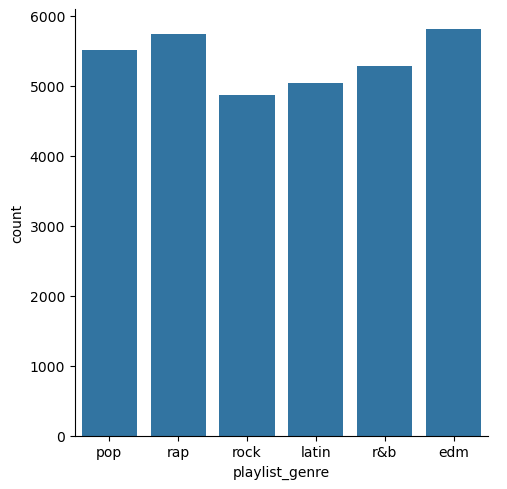

In [20]:
sns.catplot(data=spotify_copy, x='playlist_genre', kind='count')

plt.show()

**`playlist_subgenre`**:

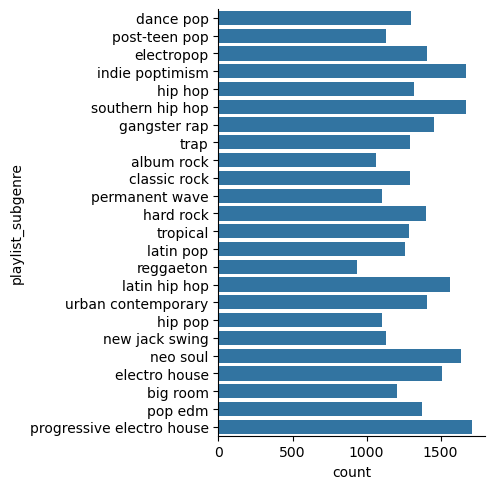

In [21]:
sns.catplot(data=spotify_copy, y='playlist_subgenre', kind='count')

plt.show()

**`mode`**:

`mode` indicates the modality of a track, with 1 representing major and 0 representing minor. To simplify this, I will change 0 to `minor` and 1 to `major` using the `.replace()` method.

In [22]:
spotify_copy['mode'] = spotify_copy['mode'].replace({0: 'minor', 1: 'major'})

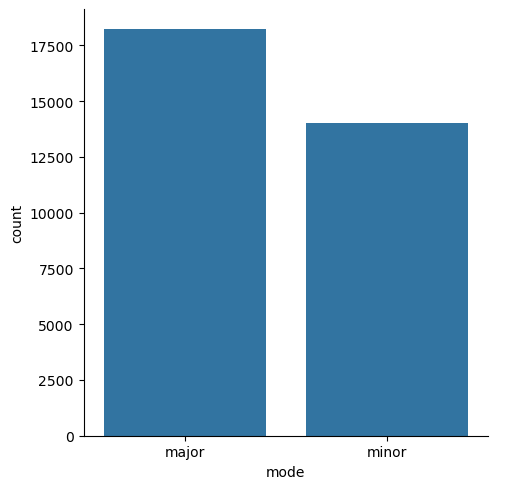

In [23]:
sns.catplot(data=spotify_copy, x='mode', kind='count')

plt.show()

**`key`**:

Just like `mode`, I will change the `key` column to update the integers to represent their actual pitch class.

In [24]:
spotify_copy['key'] = spotify_copy.key.replace({0: 'C', 1: 'C♯/D♭', 2: 'D', 3: 'D♯/E♭', 4: 'E', 5: 'F', 6: 'F♯/G♭', 7: 'G', 8: 'G♯/A♭', 9: 'A', 10: 'A♯/B♭', 11: 'B'})

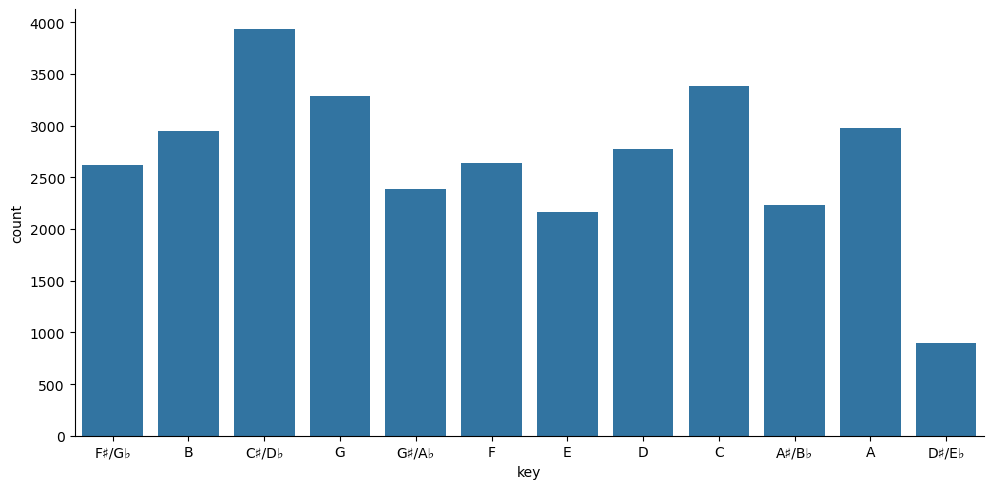

In [25]:
sns.catplot(data=spotify_copy, x='key', kind='count', aspect=2)

plt.show()

**`track_album_release_date`**:

After changing the data type of `track_album_release_date` to a `datetime` data type, we can now visualize this as a categorical variable.

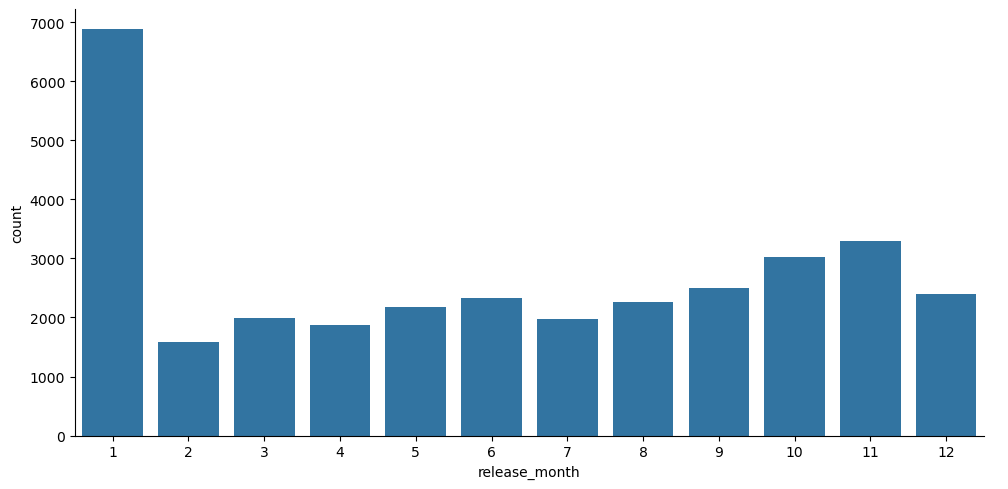

In [26]:
sns.catplot(data=spotify_copy, x='release_month', kind='count', aspect=2)

plt.show()

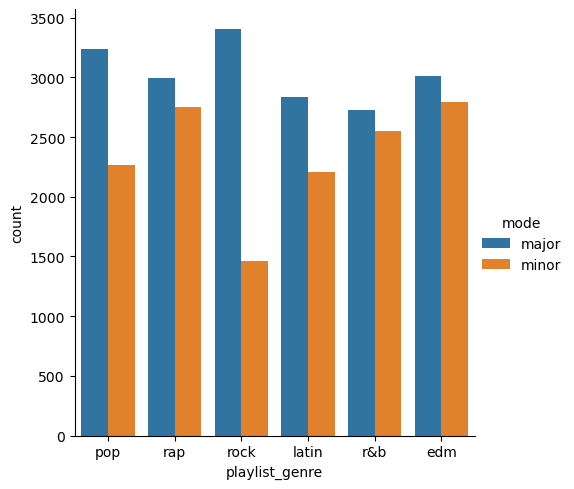

In [27]:
sns.catplot(data=spotify_copy, x='playlist_genre', hue='mode', kind='count')

plt.show()

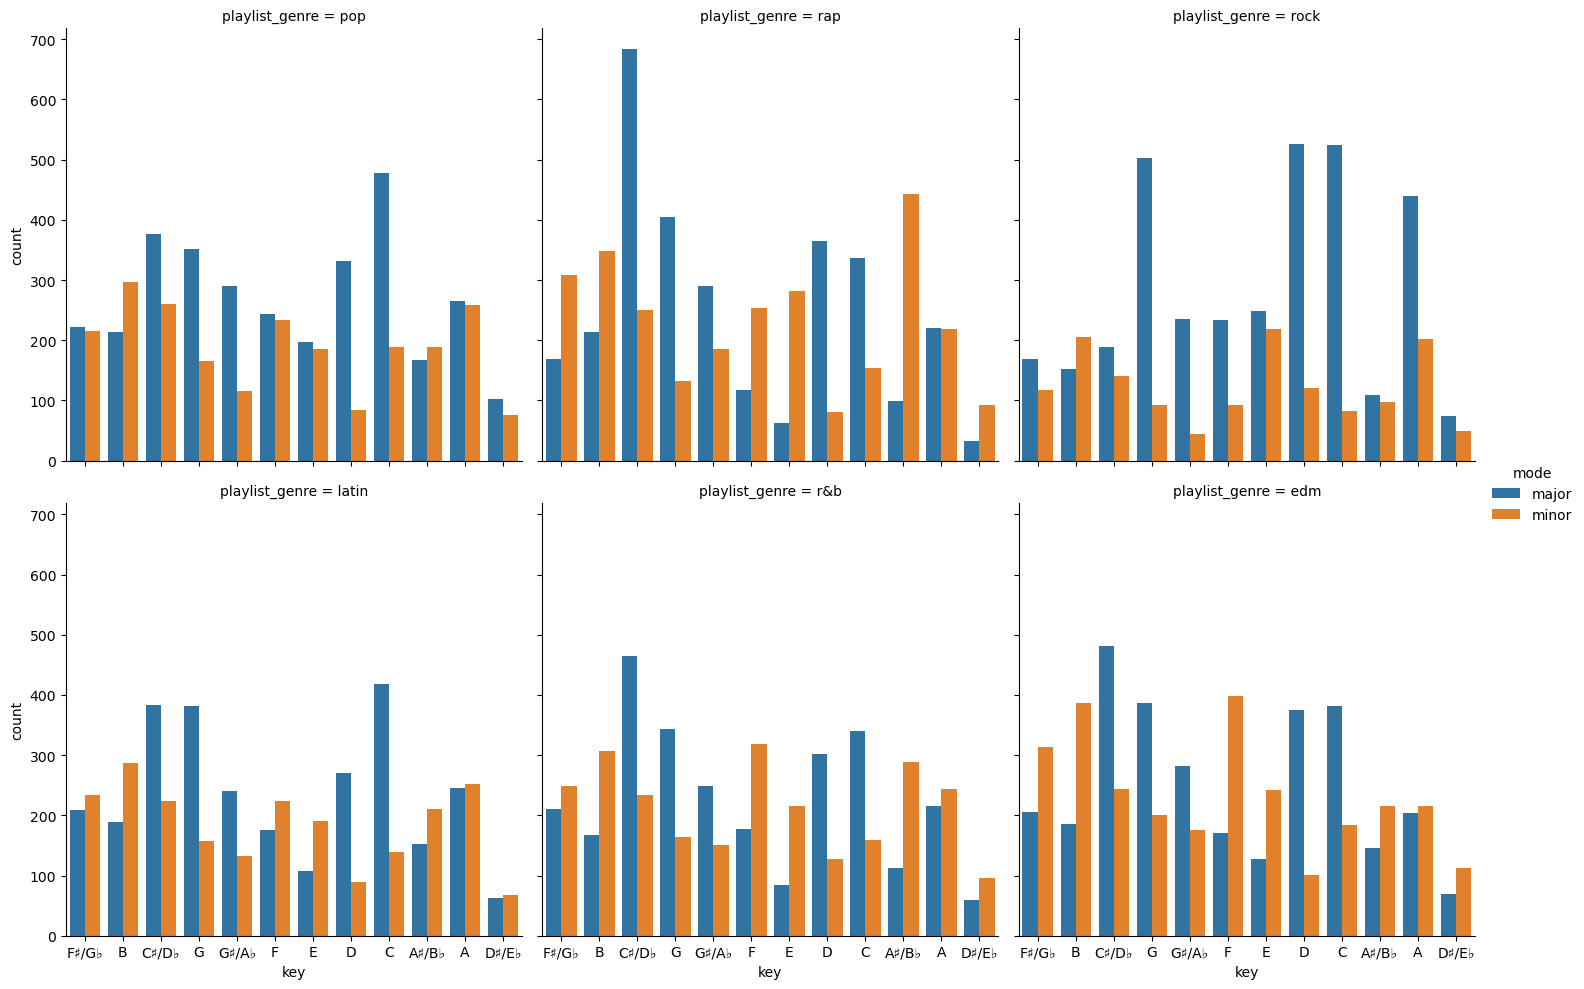

In [28]:
sns.catplot(data=spotify_copy, x='key', col='playlist_genre', hue='mode', kind='count', col_wrap=3)

plt.show()

#### Distributions of Continuous Variables

I will convert the dataset to long format so that we can visualize all of the continuous variables together.

In [29]:
spotify_lf = spotify_copy.reset_index().\
    rename(columns={'index': 'rowid'}).\
    melt(id_vars=['rowid'] + spotify_copy.select_dtypes('object').columns.tolist(),
         value_vars=spotify_copy.select_dtypes('number').copy())

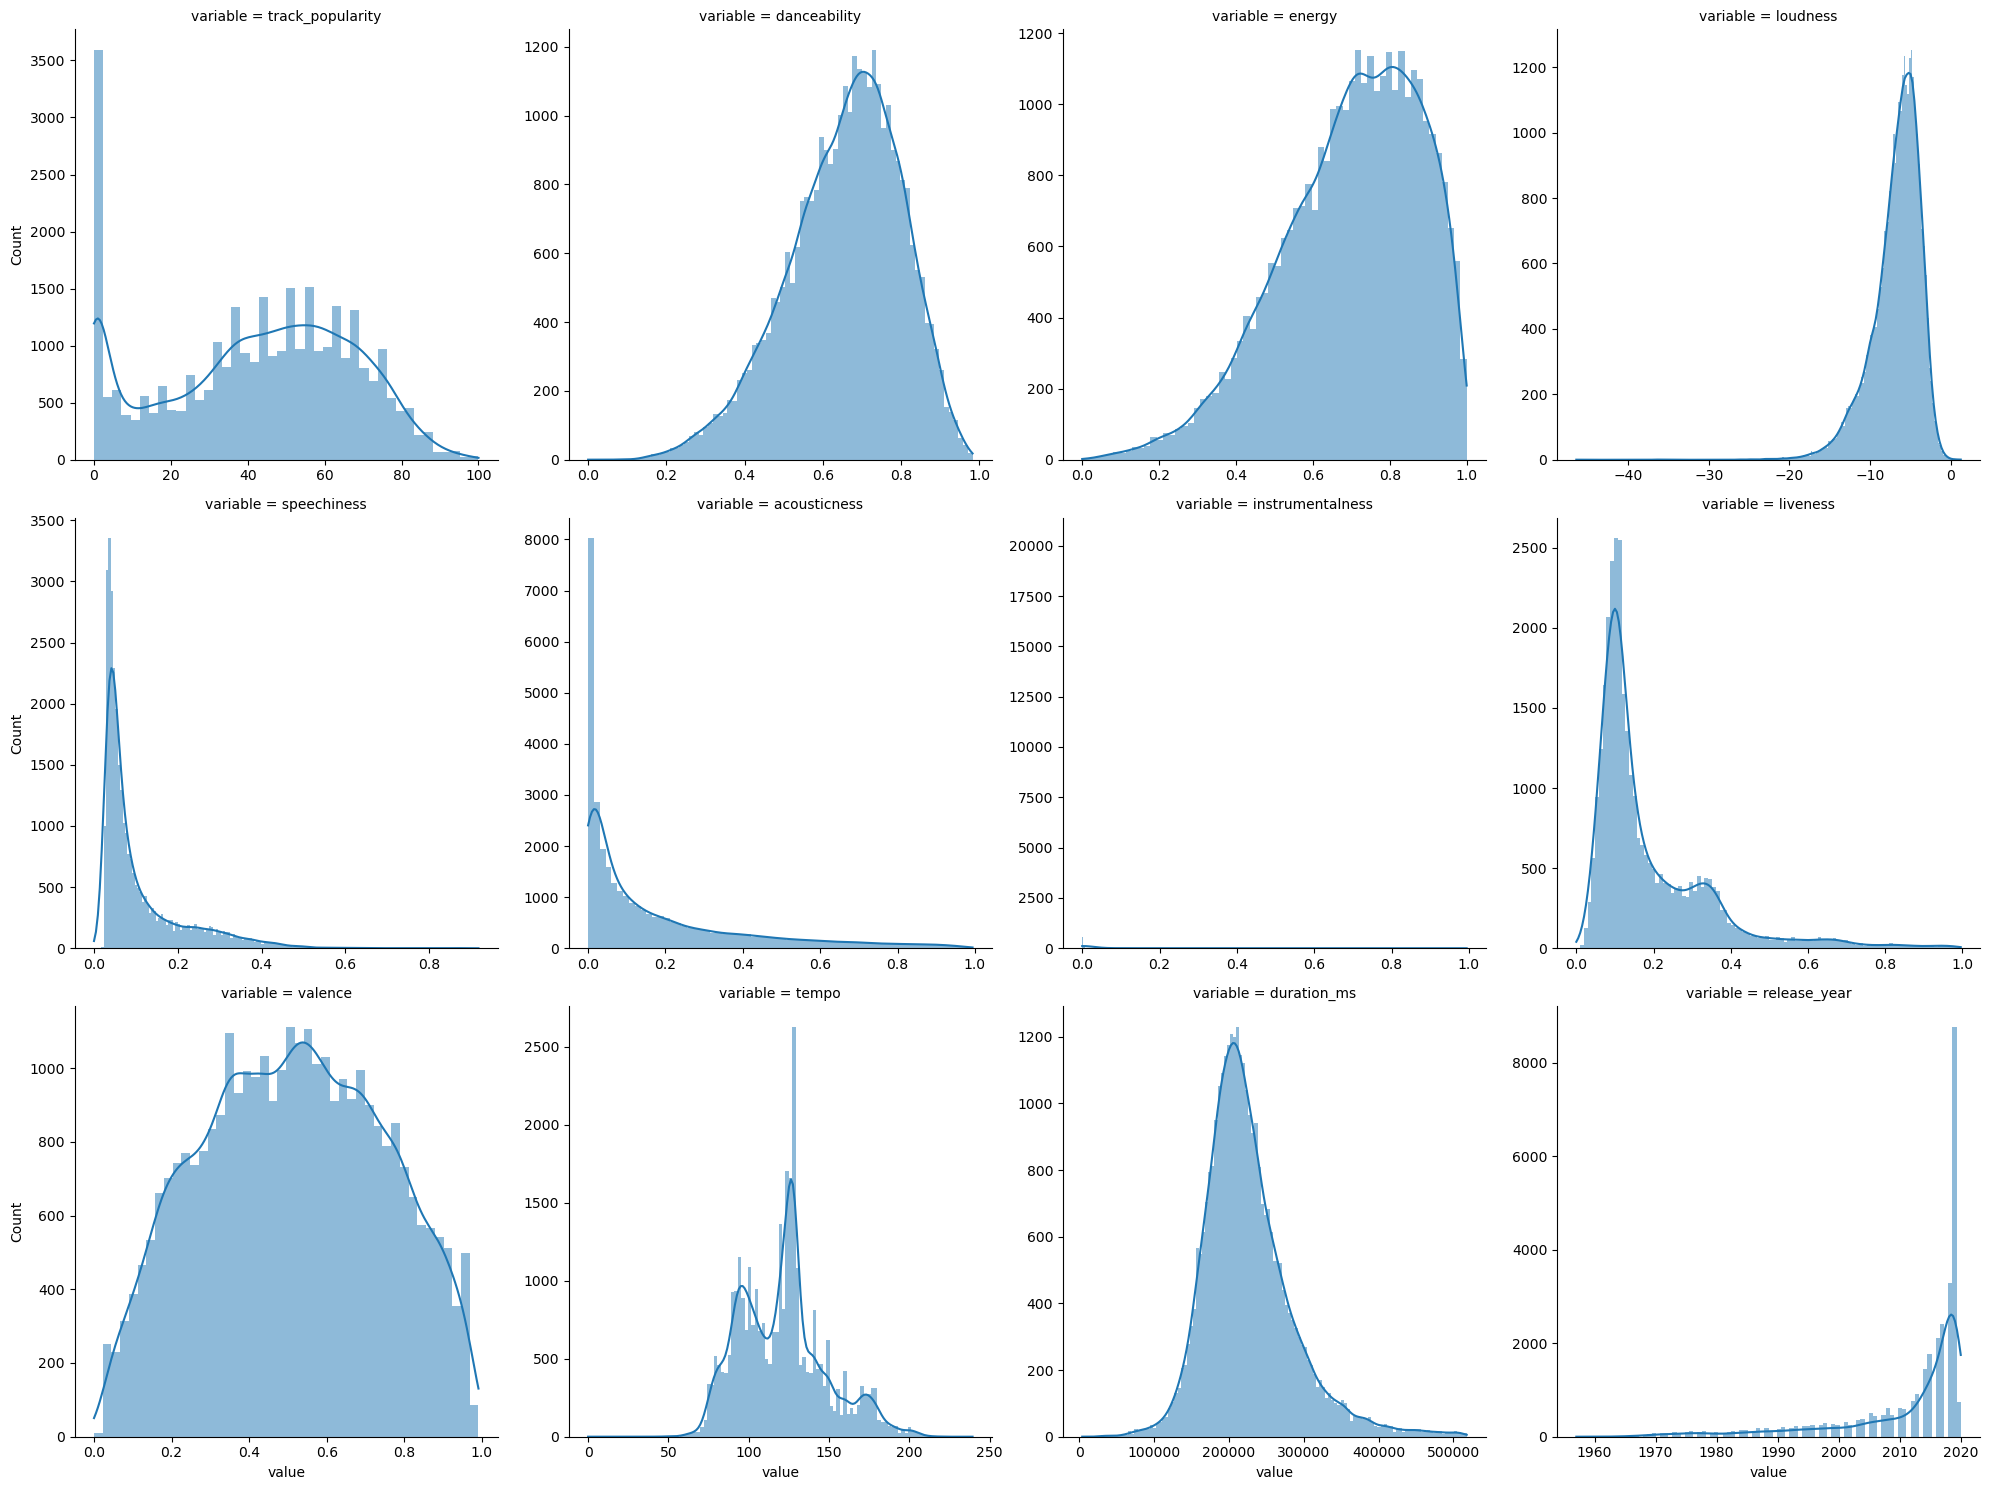

In [30]:
sns.displot(data=spotify_lf, x='value', col='variable', col_wrap=4,
            kind='hist', kde=True,
            facet_kws={'sharex': False, 'sharey': False},
            common_bins=False)

plt.show()

This visualization revealed a high density of values at and around 0 for the output variable `track_popularity` resulting in extreme skews for some of the audio features. Since I will be performing regression, I will apply some transformations the variables that do not appear to be Gaussian-like.

I will begin by applying the logit transformation to `track_popularity`.

In [31]:
spotify_copy['track_pop_shift'] = np.where( spotify_copy.track_popularity == 100, spotify_copy.track_popularity - 0.1, spotify_copy.track_popularity)

spotify_copy['track_pop_shift'] = np.where( spotify_copy.track_popularity == 0, spotify_copy.track_popularity + 0.1, spotify_copy.track_pop_shift )

The summary statistics and density are essentially identical when transformed to log-odds so the distributions are not impacted.

Now I will calculate the logit transformed output.

In [32]:
spotify_copy['y'] = np.log(
    (spotify_copy.track_pop_shift / 100) / (1 - (spotify_copy.track_pop_shift / 100))
)

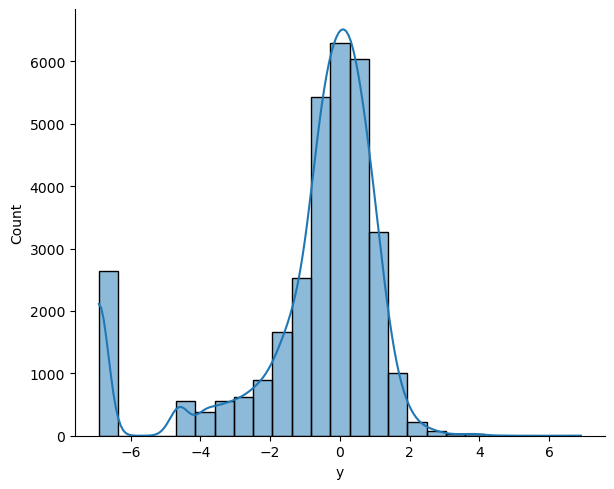

In [33]:
sns.displot(data = spotify_copy, x='y', kind='hist', kde=True, bins=25, aspect=1.25)

plt.show()

Now we can see that the distribution is mostly symmetric around 0 with a spike at `y < -6`.

I will now apply the appropriate transformation to `speechiness`.

In [34]:
spotify_copy['log_speechiness'] = np.log(spotify_copy.speechiness + 0.01)

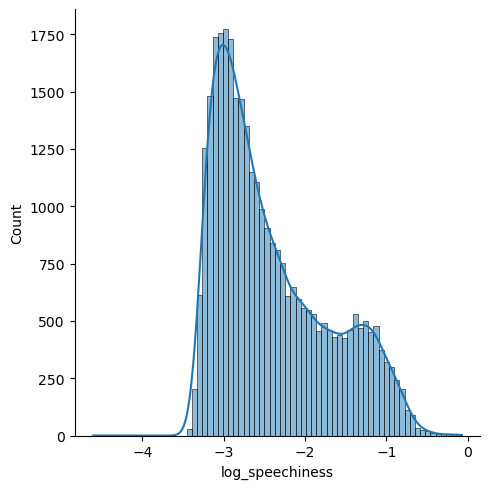

In [35]:
sns.displot(data=spotify_copy, x='log_speechiness', kind='hist', kde=True)

plt.show()

The log transformation of `speechiness` substantially reduced the original skew in `speechiness`, producing a distribution that is still right-skewed but far more symmetric and statistically manageable.”

I will now apply the logit transformation to `acousticness`.

In [36]:
spotify_copy['acoustic_shift'] = np.where( spotify_copy.acousticness == 1, spotify_copy.acousticness - 0.1, spotify_copy.acousticness)

spotify_copy['acoustic_shift'] = np.where( spotify_copy.acousticness == 0, spotify_copy.acousticness + 0.1, spotify_copy.acousticness )

In [37]:
spotify_copy['logit_acousticness'] = np.log(
    spotify_copy.acoustic_shift / (1 - (spotify_copy.acoustic_shift))
)

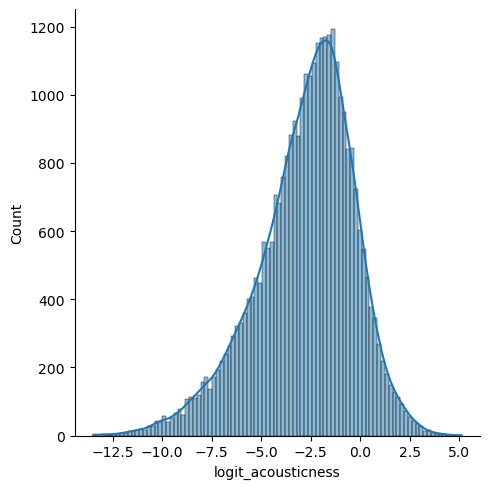

In [38]:
sns.displot(data=spotify_copy, x='logit_acousticness', kind='hist', kde=True)

plt.show()

The logit transformation did a great job at normalizing the curve for `acousticness`.

Let's apply a transformation to `liveness`. But this time, let's use the square root since the skew is not as extreme as the previous variables.

In [39]:
spotify_copy['sqrt_liveness'] = np.sqrt(spotify_copy.liveness + 0.01)

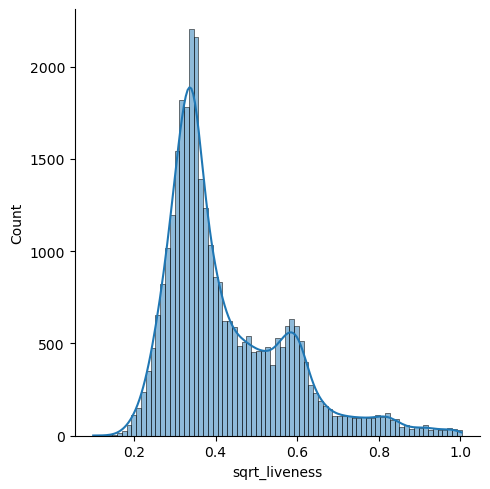

In [40]:
sns.displot(data=spotify_copy, x='sqrt_liveness', kind='hist', kde=True)

plt.show()

I will now save my cleaned and transformed dataset to a csv file for future use!

In [41]:
spotify_copy.to_csv('spotify_copy.csv', index=False)

#### Relationships Between Continuous Variables

I will now create a heatmap that shows the correlation between each feature in the dataset

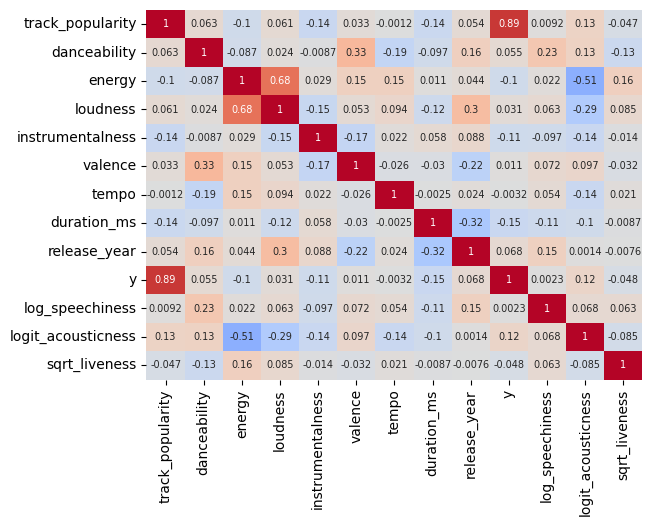

In [42]:
fig, ax = plt.subplots()

sns.heatmap(data=spotify_copy.drop(
    columns=['track_pop_shift', 'acoustic_shift', 'speechiness', 'acousticness', 'liveness']
).corr(numeric_only=True),
            vmin=-1, vmax=1, center=0,
            annot=True, annot_kws={'size': 7},
            cmap='coolwarm',
            cbar=None,
            ax=ax)

plt.show()

As we can see from the correlation heatmap, none of the continuous variables display a strong relationship to one another. `loudness` and `energy` have the highest correlation at 0.68 so I will visualize their relationship below.

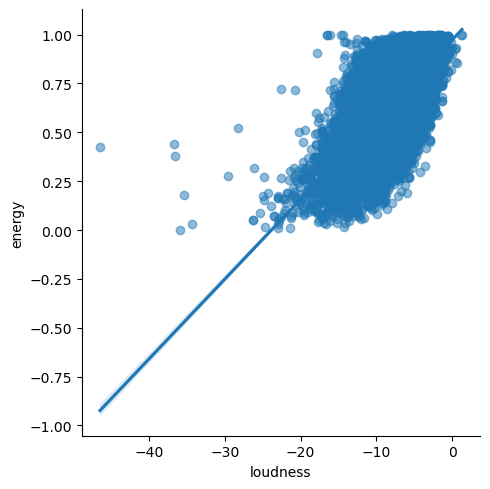

In [43]:
sns.lmplot(data=spotify_copy, x='loudness', y='energy', scatter_kws={'alpha': 0.5})

plt.show()

#### Summaries of the continuous variables grouped by categorical variables

Some of the categorical variables may have an impact on the audio features in the dataset. I will show this by creating visualizations with grouped variables>

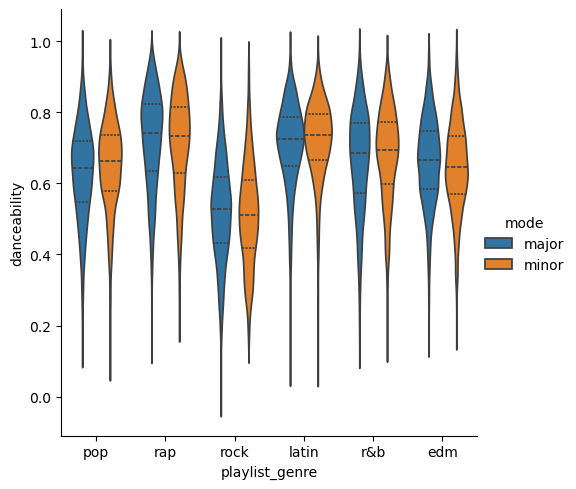

In [44]:
sns.catplot(data=spotify_copy, x='playlist_genre', y='danceability', hue='mode',
            kind='violin', inner='quartile')

plt.show()

The violin plot of `dancability` grouped by `playlist_genre` and `mode` demonstrates how the rock genre generally has a lower `danceability` score than the other genres.

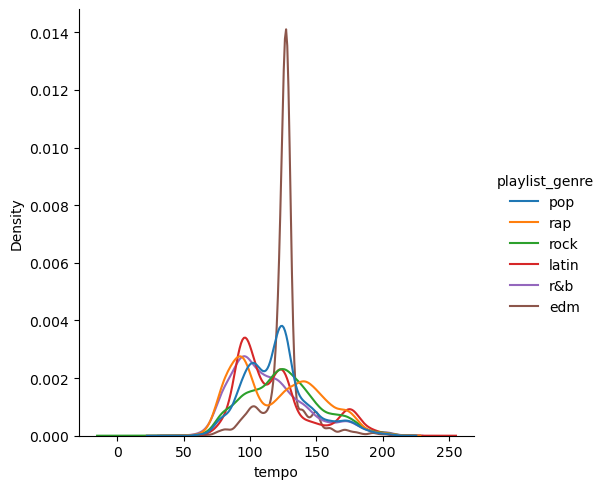

In [45]:
sns.displot(data=spotify_copy, x='tempo', hue='playlist_genre', kind='kde')

plt.show()

As we can see, the distribution of `tempo` depicts edm having a much lower level of variance than the other genres. The violin plot below further demonstrates this.

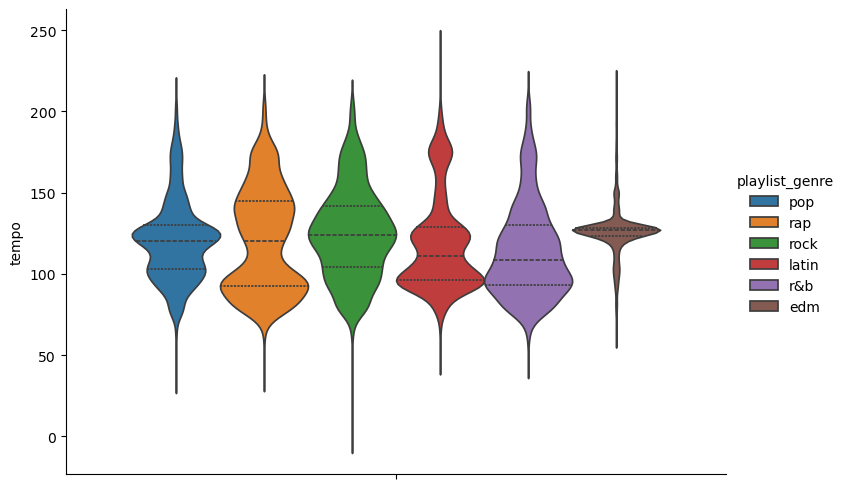

In [46]:
sns.catplot(data=spotify_copy, y='tempo', hue='playlist_genre', aspect=1.5,
            kind='violin', inner='quartile')

plt.show()

#### Visualize the Output's Relationships

I will visualize every input's relationship with the response variable, beginning with the continuous variables.

In [47]:
spotify_features = spotify_copy.select_dtypes('number').\
    drop(columns=['track_pop_shift', 'speechiness', 'acousticness', 'liveness', 'track_popularity'])

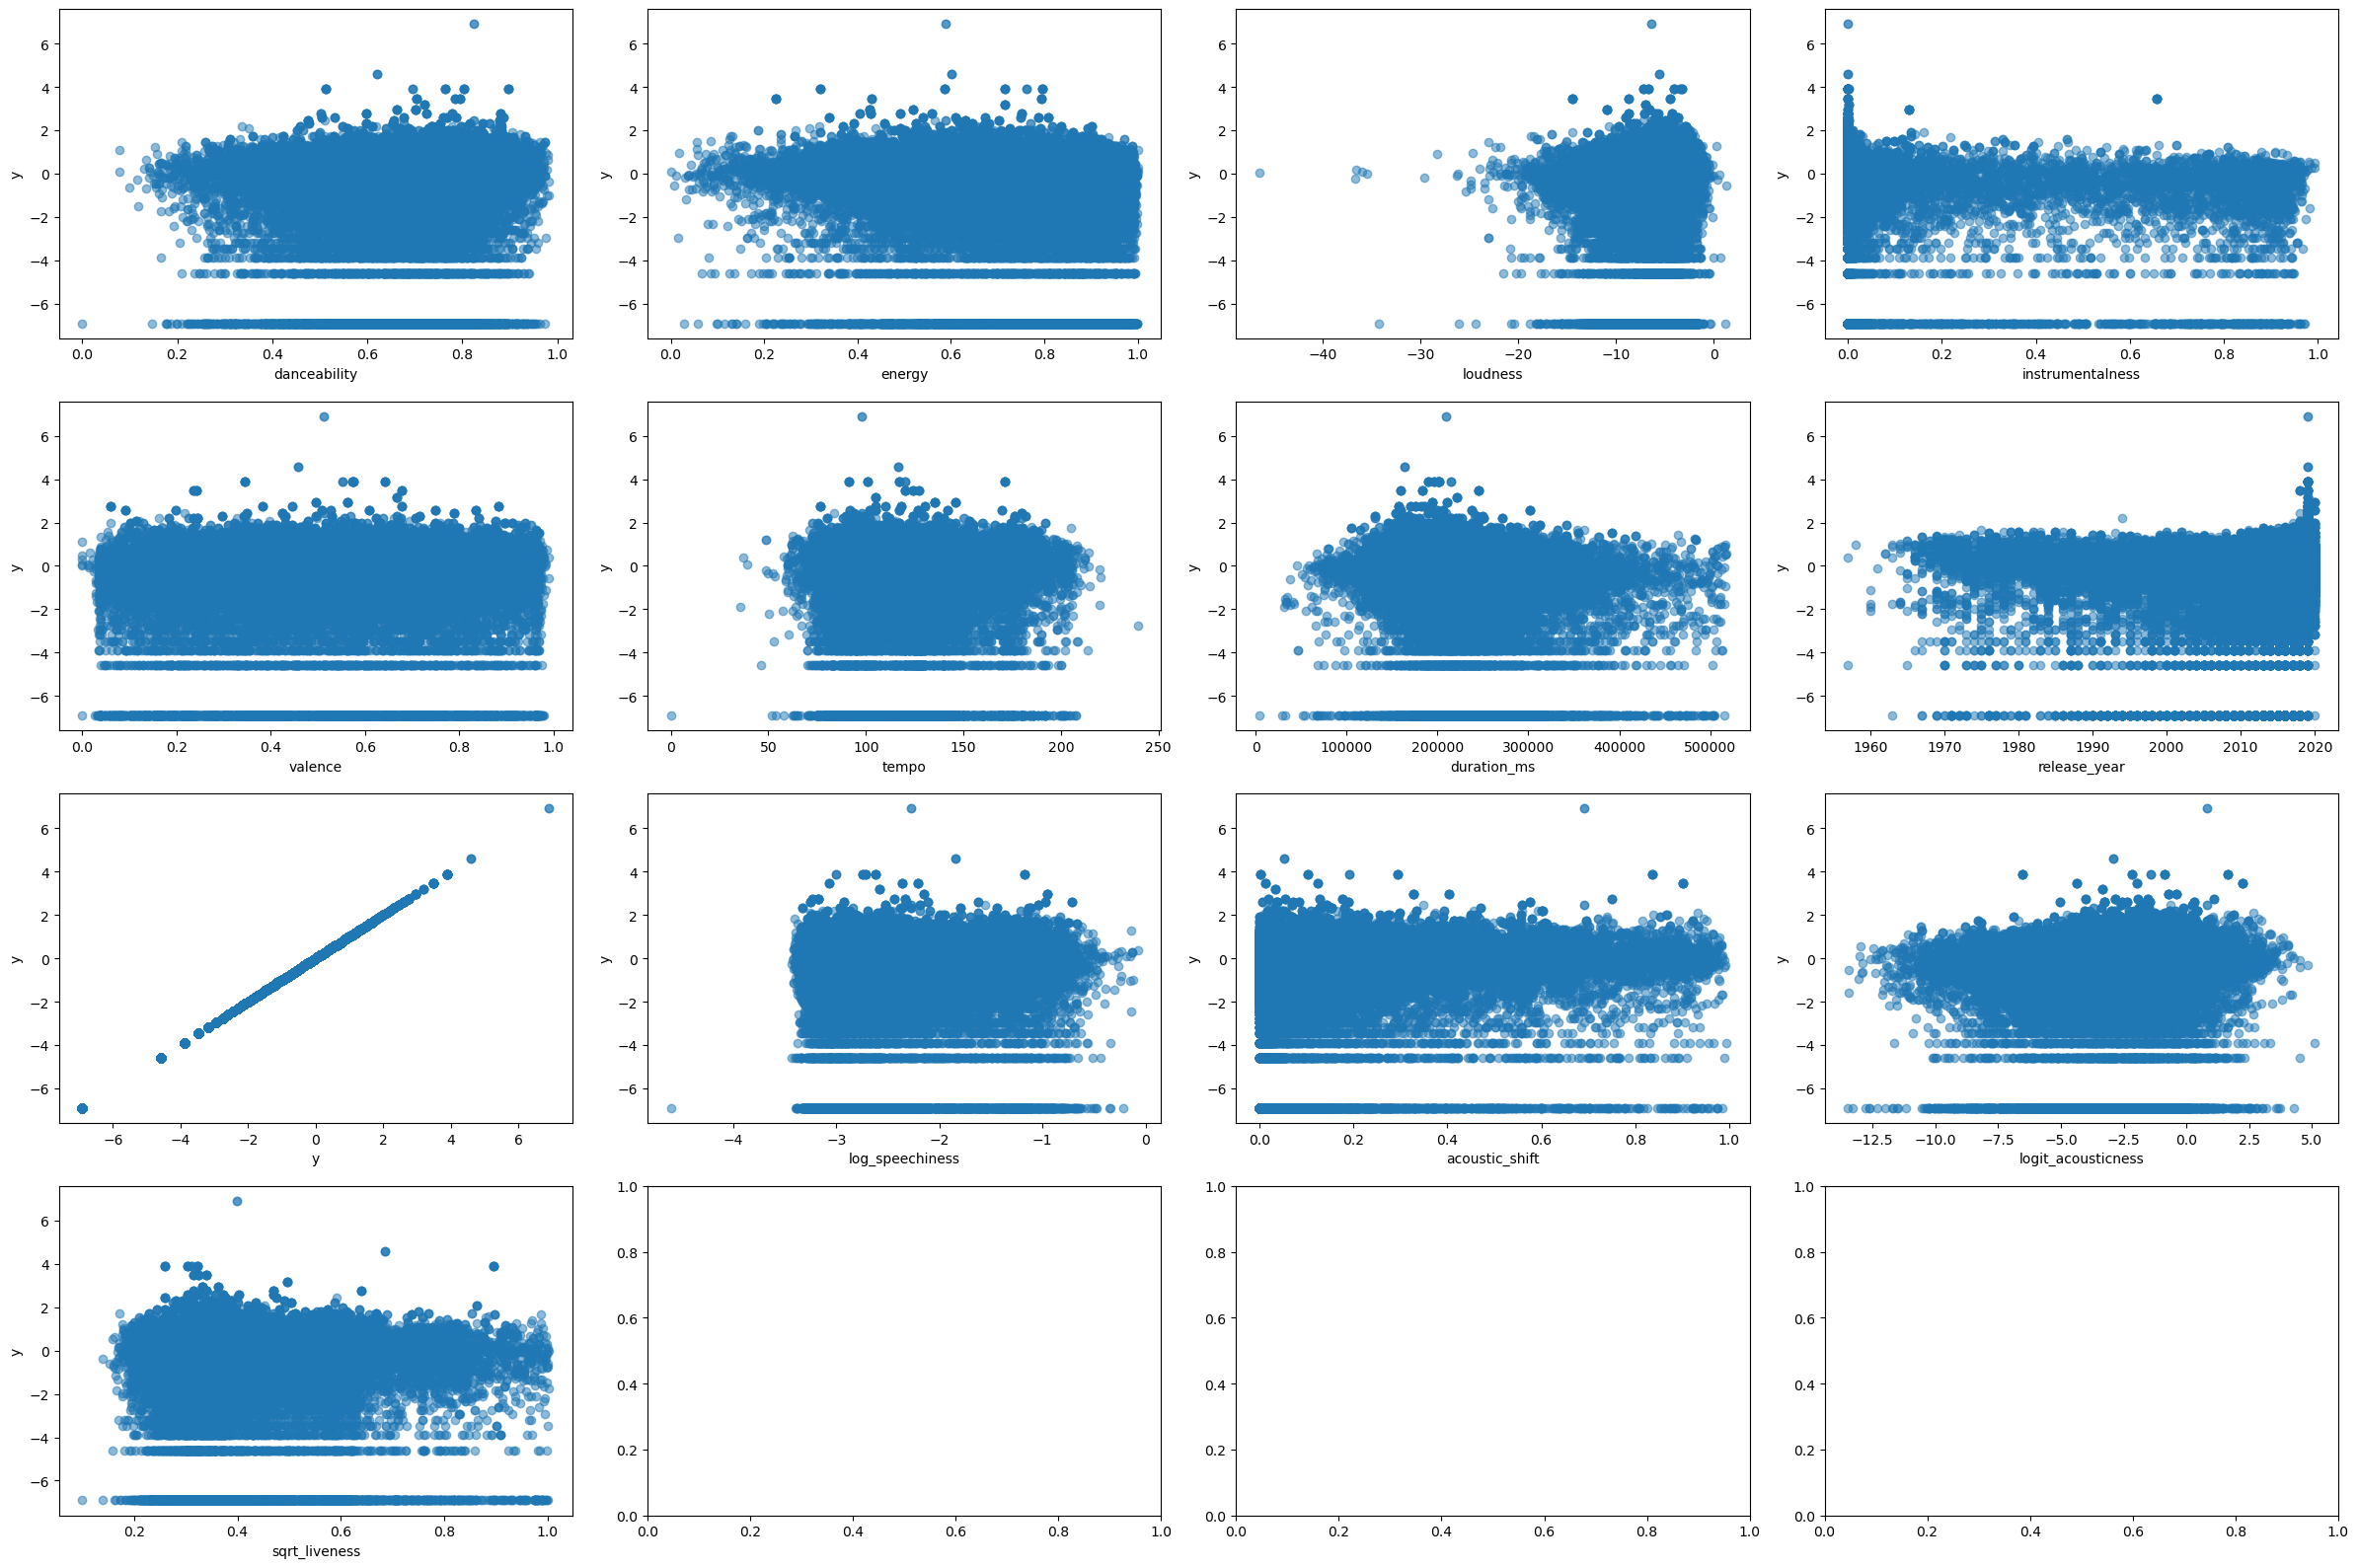

In [48]:
cols = spotify_features.columns.tolist()
n_features = len(cols)
ncols = 4
nrows = int(np.ceil(n_features / ncols))

fig, axs = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
axs = axs.flatten()

for i, n in enumerate(cols):
    axs[i].scatter(spotify_features[n], spotify_features['y'], alpha=0.5)
    axs[i].set_xlabel(n)
    axs[i].set_ylabel('y')

plt.tight_layout()
plt.show()

As we can see, there doesn't appear to be a strong relationship between the output `y` and any of the continuous inputs. This is further supported by the lack of correlation as seen in the heatmap from earlier.

I will now summarize the response for the unique values of the categorical inputs.

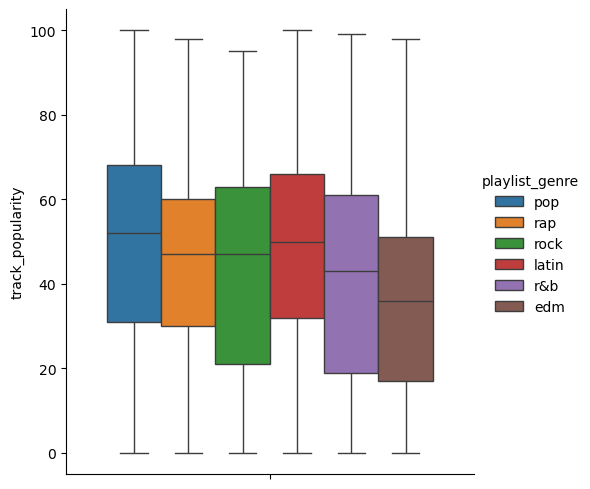

In [49]:
sns.catplot(data=spotify_copy, y='track_popularity', hue='playlist_genre', kind='box')

plt.show()

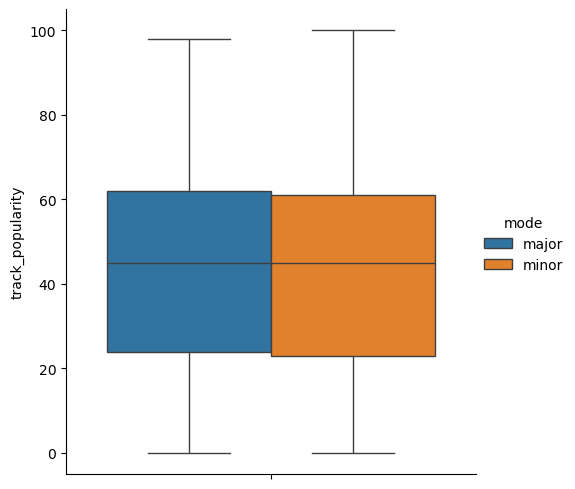

In [50]:
sns.catplot(data=spotify_copy, y='track_popularity', hue='mode', kind='box')

plt.show()

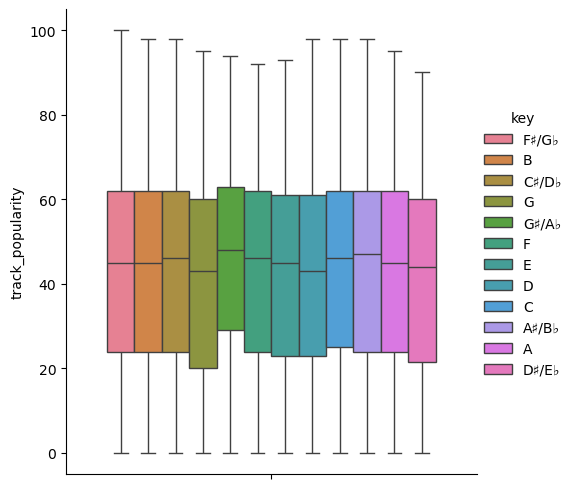

In [51]:
sns.catplot(data=spotify_copy, y='track_popularity', hue='key', kind='box')

plt.show()

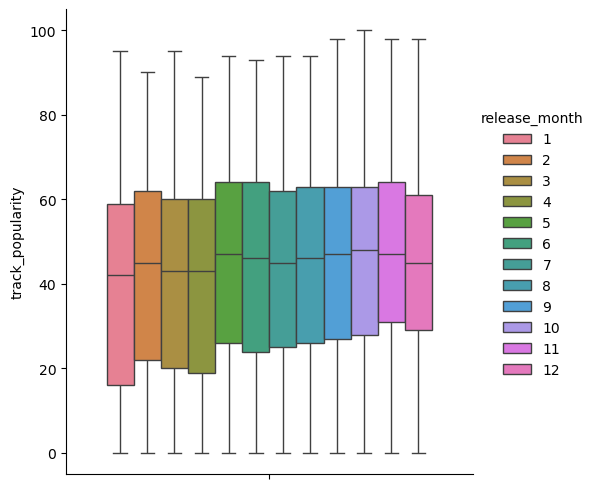

In [52]:
sns.catplot(data=spotify_copy, y='track_popularity', hue='release_month', kind='box')

plt.show()

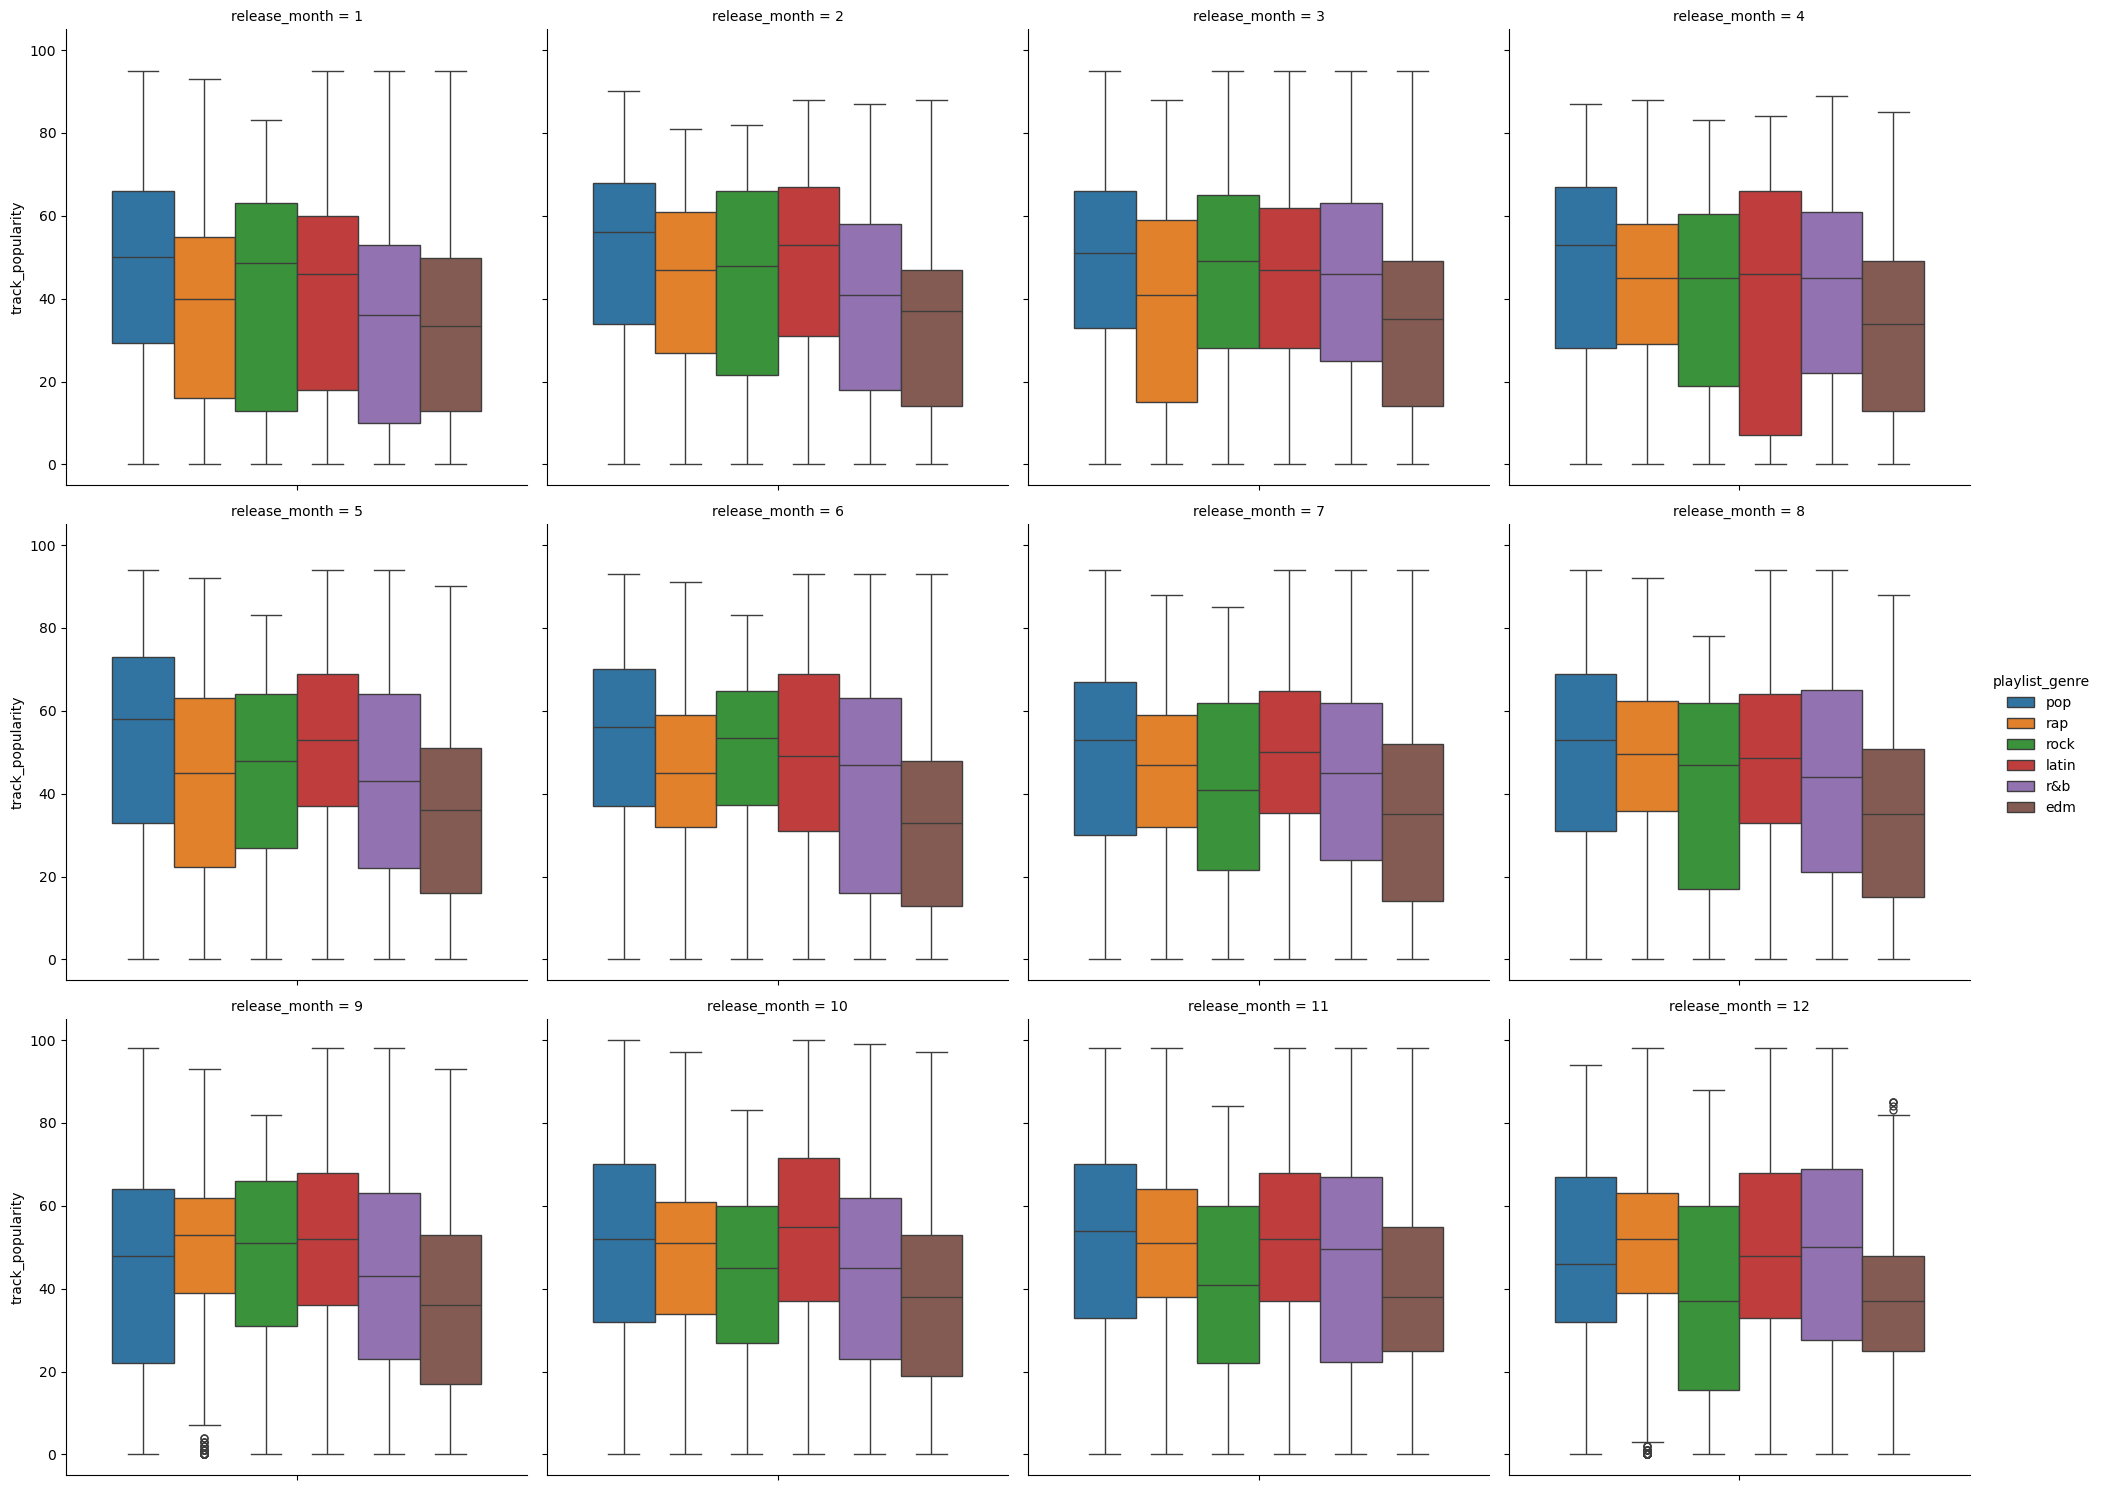

In [53]:
sns.catplot(data=spotify_copy, y='track_popularity', col='release_month', kind='box',
            hue='playlist_genre', col_wrap=4)

plt.show()

The latin genre shows to have the most variable `track_popularity` score in the 4th month of the year.

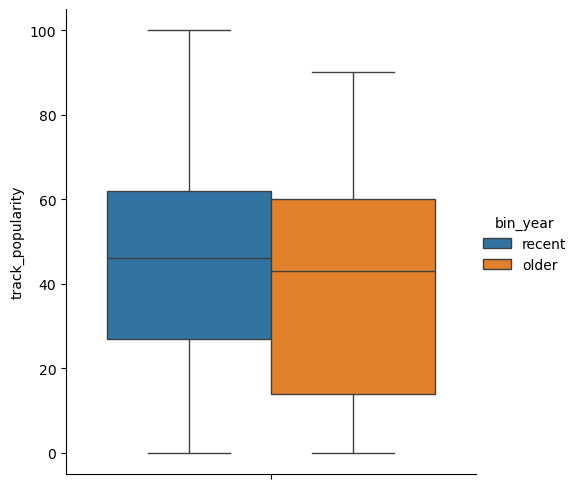

In [54]:
sns.catplot(data=spotify_copy, y='track_popularity', hue='bin_year', kind='box')

plt.show()

Based on the visualizations, the categorical variables do not appear to have a statistically significant impact on track_popularity. `playlist_genre` demonstrates some difference between some of the genres, particularly pop compared to edm, but it doesn't appear significant enough to draw any conclusions.

## Clustering

Before I begin clustering, I will perform principal component analysis because of the high dimension of the dataset.

I will know import `PCA()` from `sklean.decomposition`.

In [55]:
from sklearn.decomposition import PCA

I will now create a NEW DataFrame consisting of all the continuous variables to be used for PCA.

In [56]:
pca_features = spotify_copy.loc[ :,
    ['danceability',
    'energy',
    'loudness',
    'instrumentalness',
    'valence',
    'tempo',
    'duration_ms',
    'log_speechiness',
    'sqrt_liveness',
    'logit_acousticness']
].copy()

In [57]:
pca_features.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32246 entries, 0 to 32832
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   danceability        32246 non-null  float64
 1   energy              32246 non-null  float64
 2   loudness            32246 non-null  float64
 3   instrumentalness    32246 non-null  float64
 4   valence             32246 non-null  float64
 5   tempo               32246 non-null  float64
 6   duration_ms         32246 non-null  int64  
 7   log_speechiness     32246 non-null  float64
 8   sqrt_liveness       32246 non-null  float64
 9   logit_acousticness  32246 non-null  float64
dtypes: float64(9), int64(1)
memory usage: 2.7 MB


I now need to standardize the PCA features.

In [58]:
from sklearn.preprocessing import StandardScaler

In [59]:
Xpca = StandardScaler().fit_transform(pca_features)

In [60]:
Xpca.shape

(32246, 10)

To help determine the appropriate number of components to use for PCA in this high-dimensional dataset, I will create a cumulative explained variance plot.

In [61]:
scaler = StandardScaler()

In [62]:
pca = PCA().fit(Xpca)

Because of the very high dimension of the data, I will only select the number of components that most closely aligns with 75% of the variance.

I will now visualize the cumulative explained variance in a plot below with a horizontal axis line at 0.75.

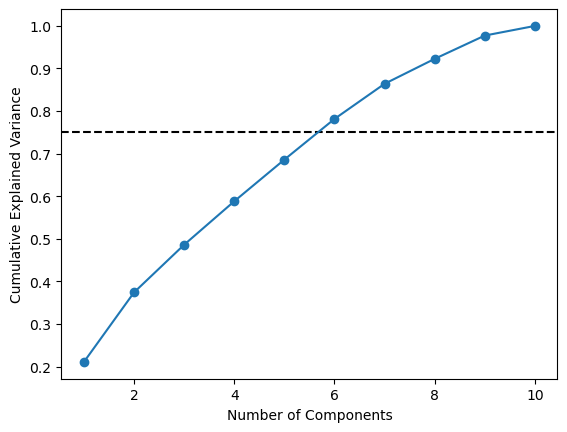

In [63]:
fig, ax = plt.subplots()

# 75% threshold
plt.axhline(y=0.75, color='k', linestyle='--')

# explained variance line
plt.plot(range(1, len(pca.explained_variance_ratio_.cumsum()) + 1), pca.explained_variance_ratio_.cumsum(), marker='o')

# plot labels
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')

plt.show()

As we can see, 6 components most closely aligns with 75% of the explained variance, so I will now create my PCA objects with `n_components=6`.

In [64]:
pca_spotify = PCA(n_components=6).fit_transform(Xpca)

Now, I will convert `spotify_pca` from a NumPy array to a DataFrame.

In [65]:
spotify_pca_df = pd.DataFrame( pca_spotify, columns=['pc%02d' % d for d in range(1, pca_spotify.shape[1]+1)] )

In [66]:
spotify_pca_df.head()

,pc01,pc02,pc03,pc04,pc05,pc06
0,1.068365,1.041972,-0.499168,-0.208525,-0.752665,-1.156694
1,0.655499,0.981966,0.097355,-0.630794,1.244742,-0.917373
2,1.219343,1.067121,-0.023497,-0.181314,-0.535181,-0.912090
3,1.435695,0.541804,0.658283,0.525984,0.252263,-0.927856
4,0.640522,0.679271,-0.517798,-0.771880,-0.827203,-0.979934


As we can see from the heatmap, PCA is created such that none of the new variables are correlated.

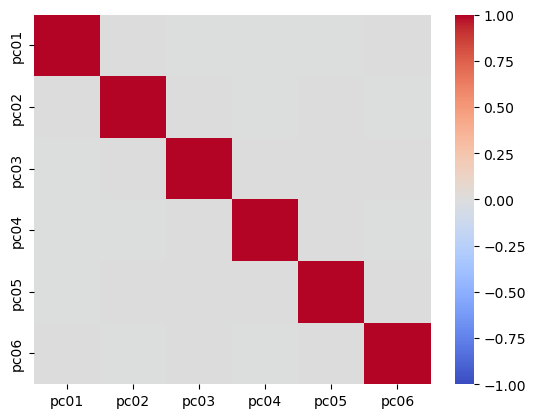

In [67]:
fig, ax = plt.subplots()

sns.heatmap(data=spotify_pca_df.corr(numeric_only=True),
            vmin=-1, vmax=1, center=0,
            cmap='coolwarm',
            ax=ax)

plt.show()

Now we can begin clustering!

### Hierarchical Clustering

For clustering, I will use hierarchical clustering with Ward's method because it works especially well on PCA-transformed data and tends to create clearer, more meaningful groups than other methods.

Import `hierarchy` from `scipy.cluster`.

In [68]:
from scipy.cluster import hierarchy

In [69]:
hclust_ward = hierarchy.ward(spotify_pca_df)

Visualize the ward dendogram.

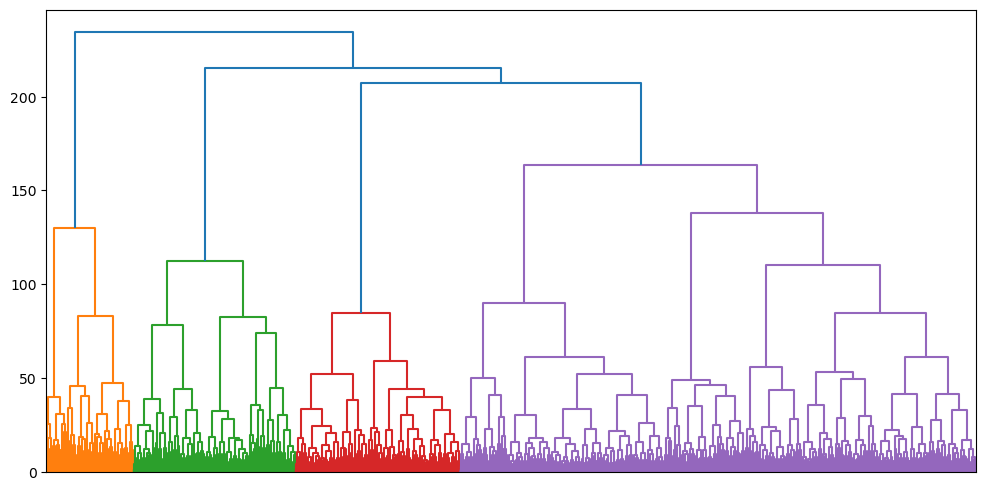

In [70]:
fig = plt.figure(figsize=(12, 6))

dn = hierarchy.dendrogram( hclust_ward, no_labels=True )

plt.show()

The ward method suggests that the ideal number of clusters is 4 and after cutting the tree (shown in my supporting documents), we can see that the jumps begin to get bigger and bigger after 4 clusters.

I will now add the clusters to `spotify_pca_df` using `fcluster`.

In [71]:
from scipy.cluster.hierarchy import fcluster

In [72]:
spotify_pca_df['h4'] = pd.Series(
    fcluster(hclust_ward, 4, criterion='maxclust'), index=spotify_pca_df.index
).astype('category')

The pairplot for `spotify_pca_df` with `hue='h4'` is shown below.

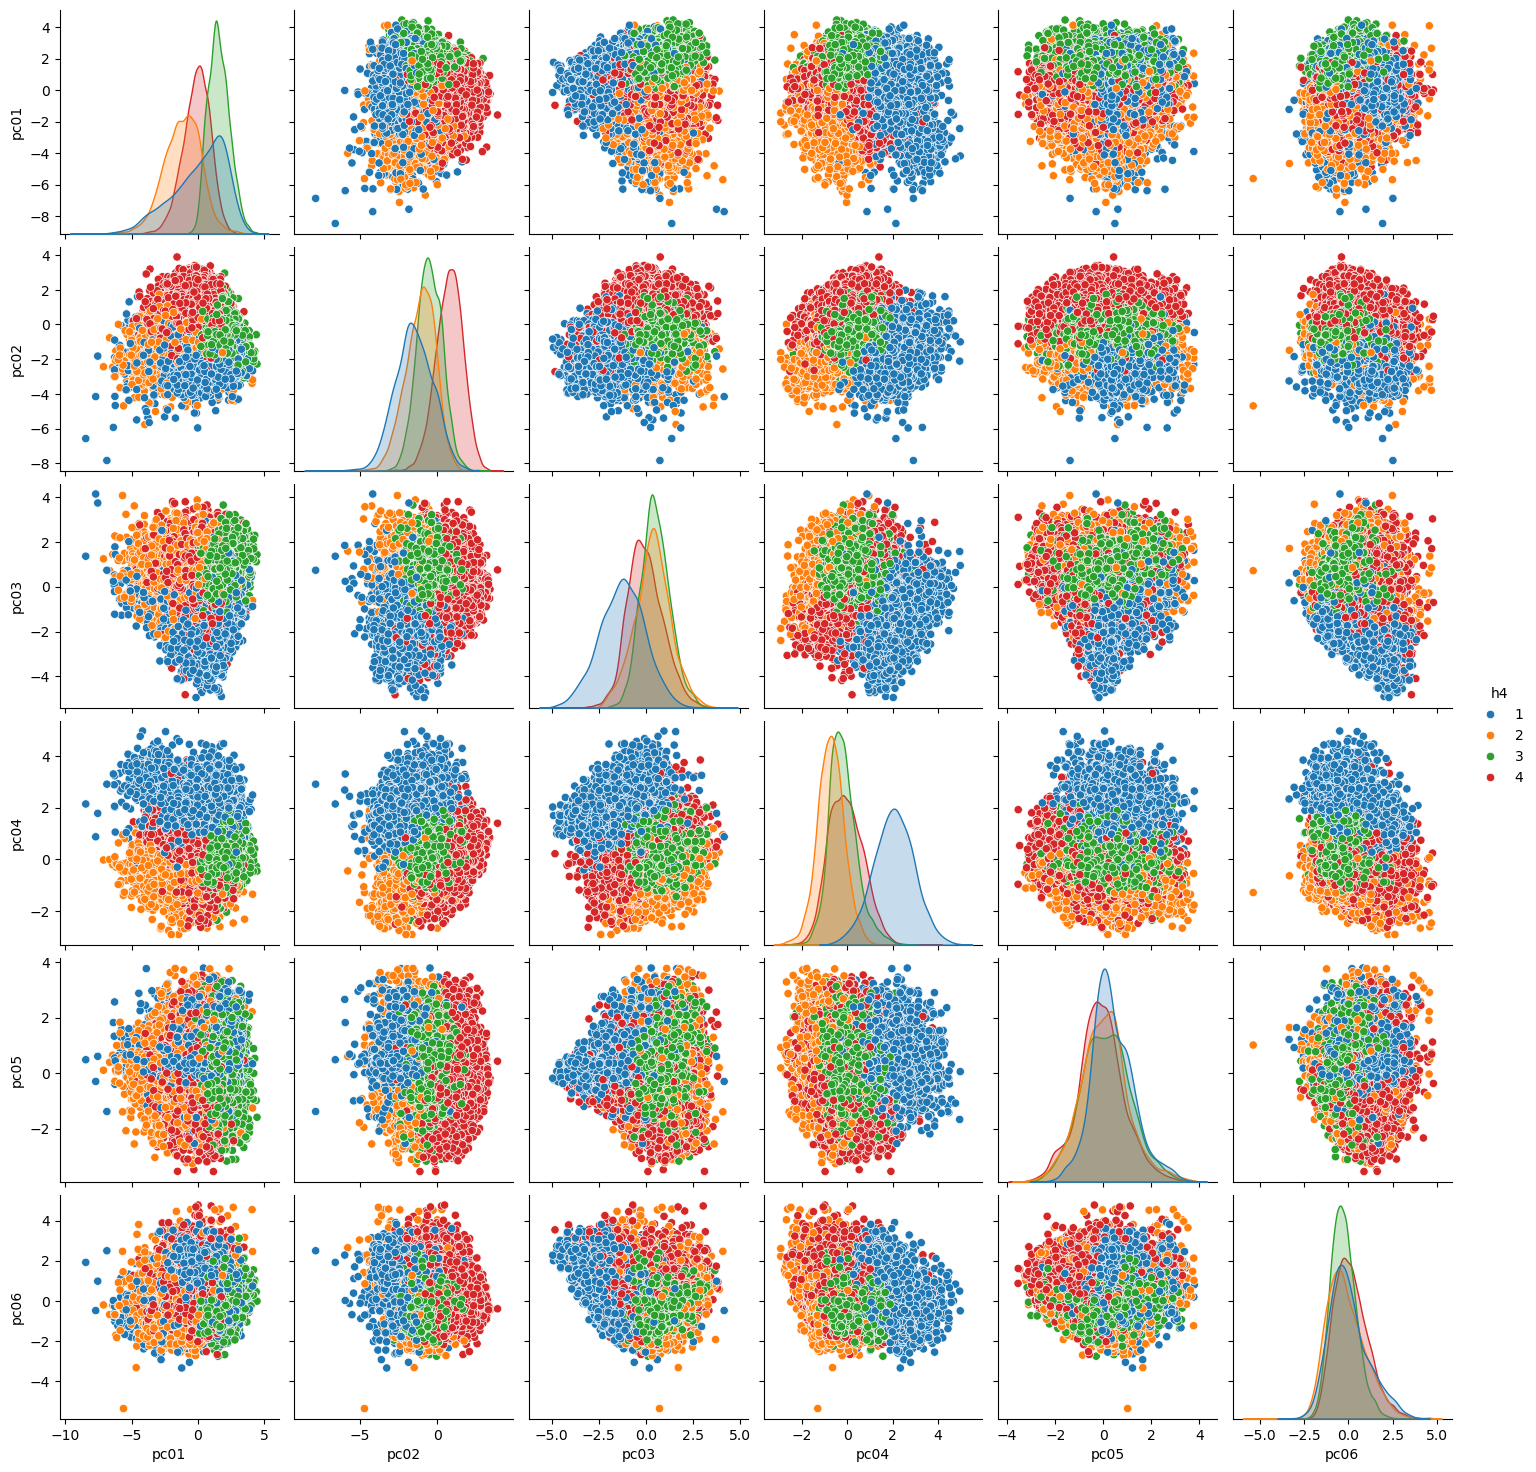

In [73]:
sns.pairplot(data=spotify_pca_df, hue='h4', diag_kws={'common_norm': False})

plt.show()

Combine the hierarchical clusters with `spotify_copy`.

In [74]:
spotify_copy['h4'] = spotify_pca_df['h4']

#### Distributions across continuous variables

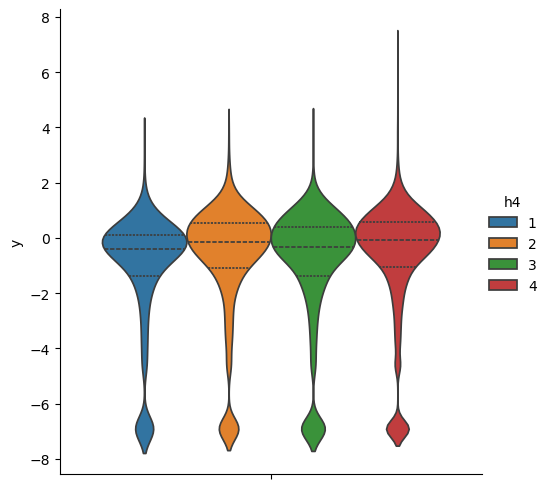

In [75]:
sns.catplot(data=spotify_copy, y='y', hue='h4', kind='violin', inner='quartile')

plt.show()

The violin plot above shows cluster 3 having the most variability in the output variable `y`, but also reaches the highest values. This suggests that cluster 3 may contain more popular tracks than the others and could potentially be used as a predictor.

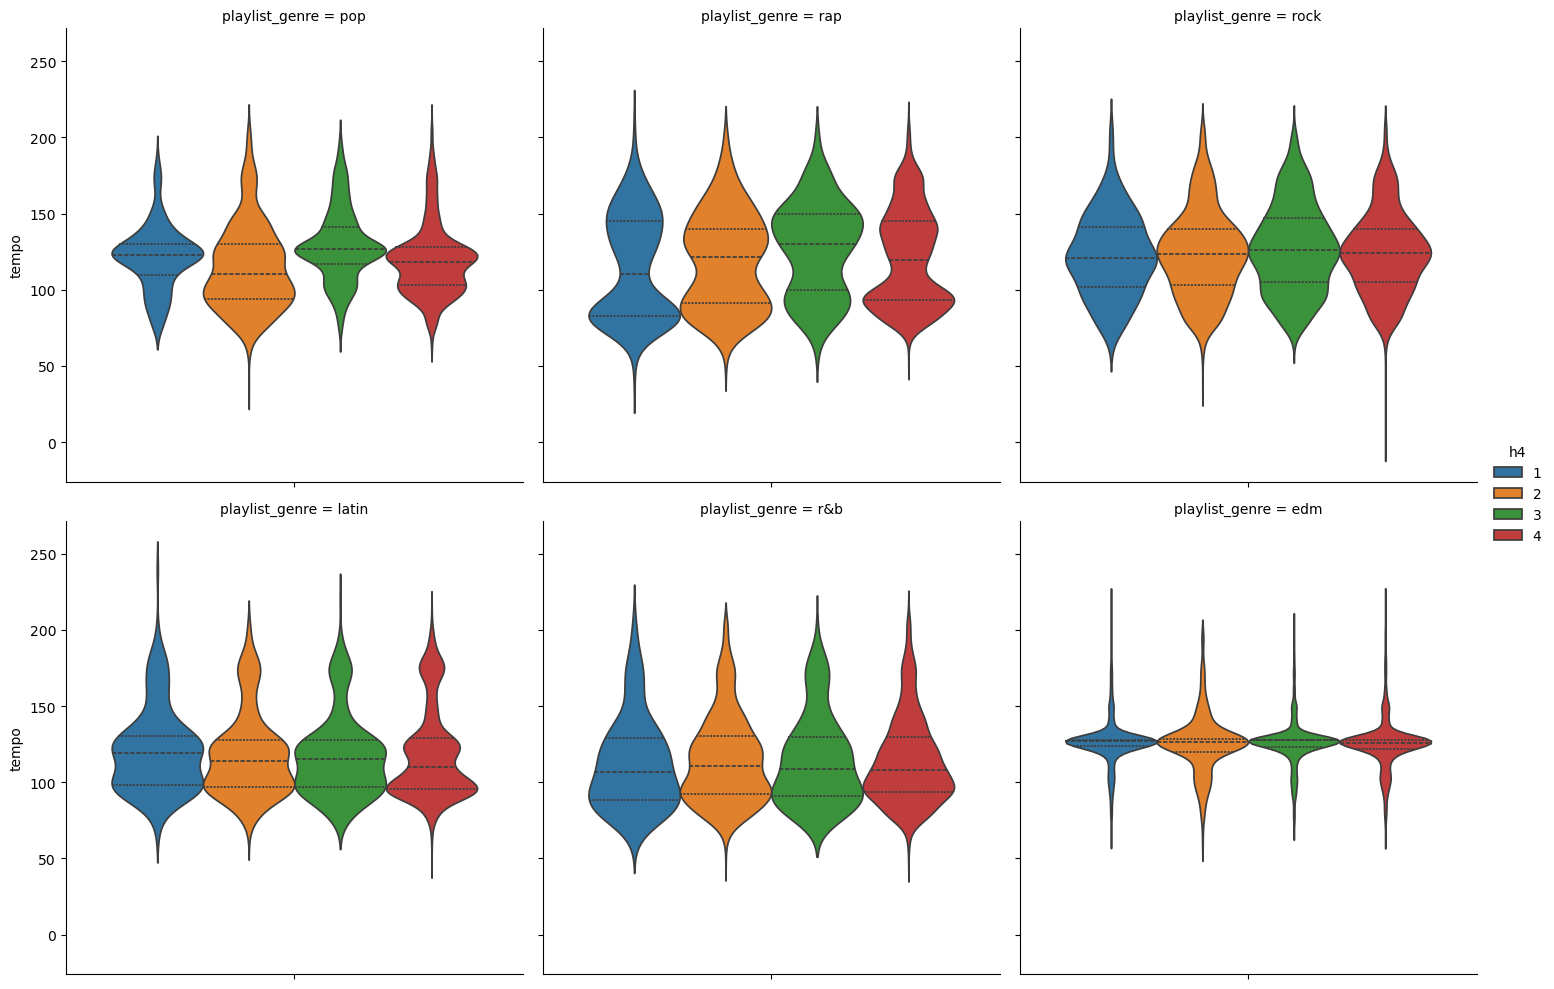

In [76]:
sns.catplot(data=spotify_copy, y='tempo', hue='h4', col='playlist_genre', col_wrap=3,
            kind='violin', inner='quartile')

plt.show()

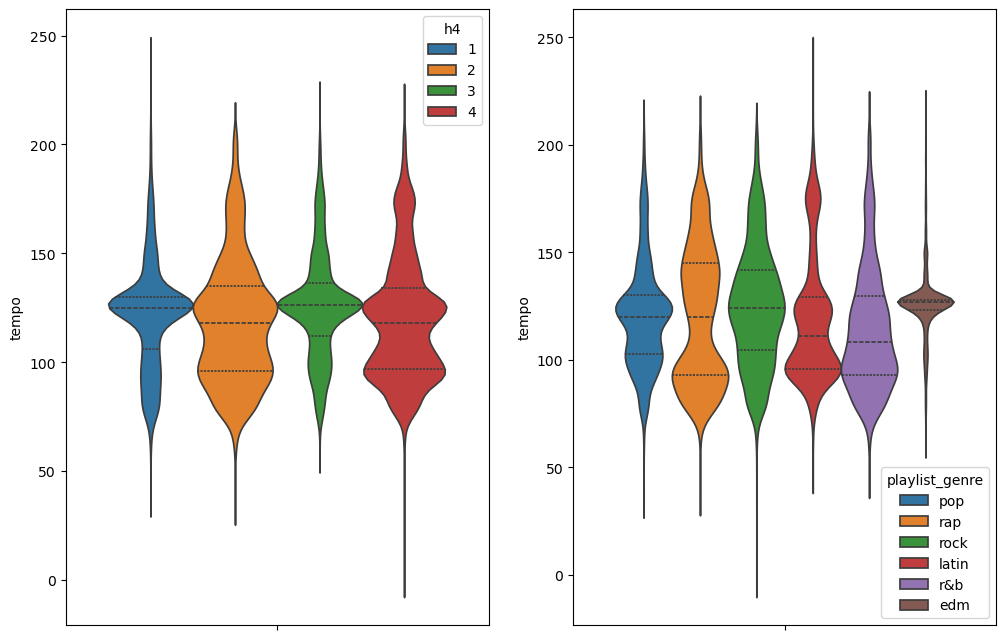

In [77]:
fig, ax = plt.subplots(1, 2, figsize=(12,8))

sns.violinplot(data=spotify_copy, y='tempo', hue='h4', inner='quartile', ax=ax[0])

sns.violinplot(data=spotify_copy, y='tempo', hue='playlist_genre', inner='quartile', ax=ax[1])

plt.show()

When faceting `tempo` by `playlist genre`, cluster 1 shows a consistently narrow distribution centered around approximately 120–130 BPM. Interestingly, this tempo range aligns with the central peak of the EDM genre's tempo distribution. While this does not imply that Cluster 1 is genre-specific, it suggests that many songs in this cluster share tempo characteristics commonly found in EDM tracks.

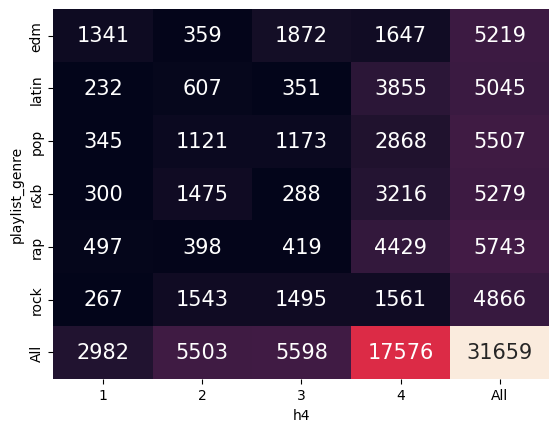

In [78]:
fig, ax = plt.subplots()

sns.heatmap(data=pd.crosstab(spotify_copy['playlist_genre'], spotify_copy.h4, margins=True),
            annot=True, annot_kws={'fontsize': 15}, fmt='d',
            cbar=False)

plt.show()

The results from the heatmap show no strong alignment between `h4` and `playlist_genre`. Although cluster 1 shows meaningful audio patterns and characteristics that align with the EDM genre, the cluster is not EDM specific.

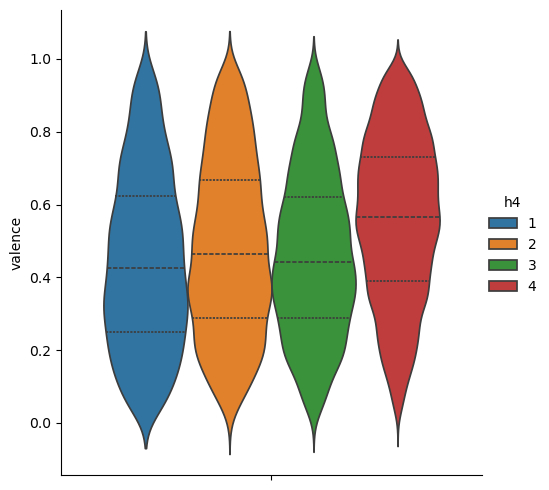

In [79]:
sns.catplot(data=spotify_copy, y='valence', hue='h4', kind='violin', inner='quartile')

plt.show()

According to the violin plot, there is a clear separation between cluster 3 and all other clusters across `valence`. This suggests that cluster 3 may contain more positive and cheerful songs than the other clusters.

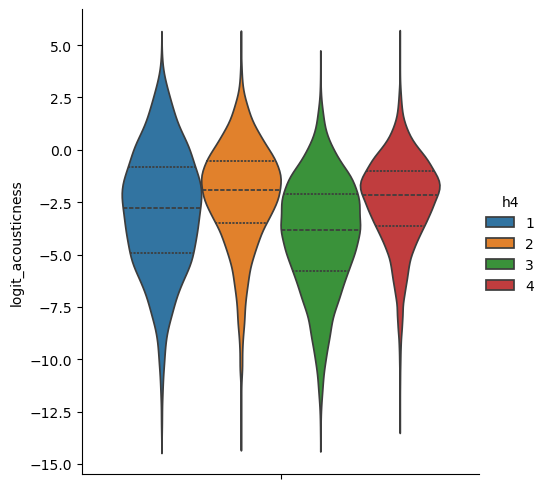

In [80]:
sns.catplot(data=spotify_copy, y='logit_acousticness', hue='h4', kind='violin', inner='quartile')

plt.show()

“The relationship between the `h4` clusters and `logit_acousticness` shows clear separation across the clusters. Cluster 1 has the lowest acousticness values and the greatest variability, suggesting it contains a diverse mix of low-acoustic tracks. In contrast, Cluster 4 has substantially higher `logit_acousticness` values with a tighter distribution, indicating it represents the most acoustic songs. Clusters 2 and 3 fall between these extremes, forming an ordered progression from low- to high-acousticness.”

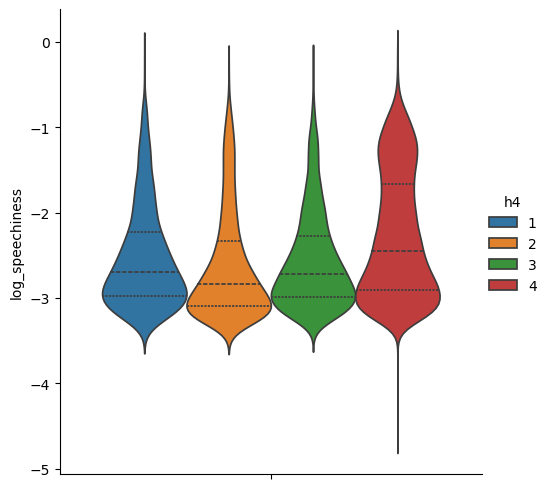

In [81]:
sns.catplot(data=spotify_copy, y='log_speechiness', hue='h4', kind='violin', inner='quartile')

plt.show()

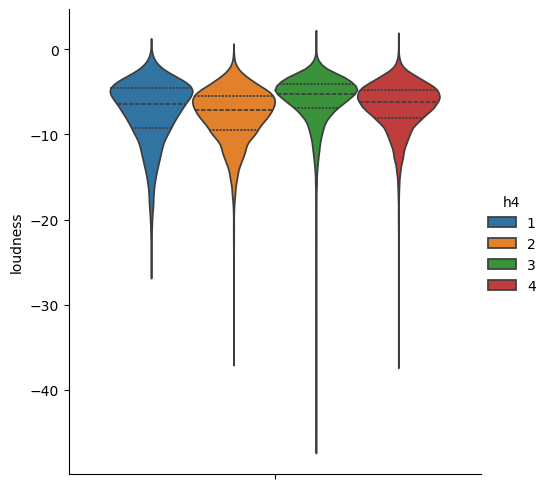

In [82]:
sns.catplot(data=spotify_copy, y='loudness', hue='h4', kind='violin', inner='quartile')

plt.show()

Across `log_speechiness` and `loudness`, the `h4` clusters show modest but noticeable differences. Cluster 1 has the lowest speechiness, while clusters 2 and 3 are slightly higher. Cluster 4 stands out with the highest `log_speechiness` and the widest `loudness` range, suggesting a more varied mix of tracks.

The plot below shows how cluster 4 is more associated with lower-energy tracks in the data. This aligns with what we previously observed with the relationship between cluster 4 with `loudness` and `logit_acousticness`. Low-energy tracks are also likely to have low levels of loudness and acousticness since these variables have a moderately strong correlation.

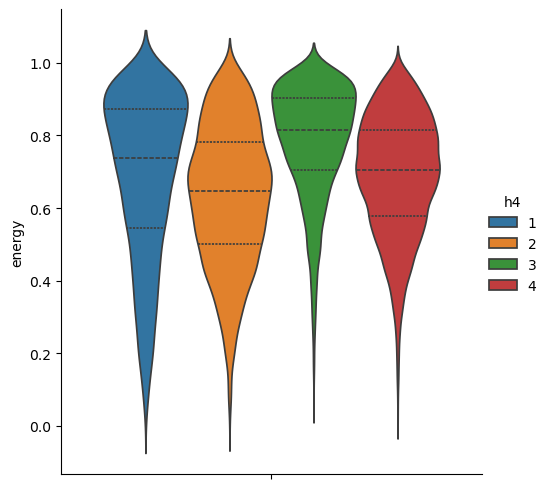

In [83]:
sns.catplot(data=spotify_copy, y='energy', hue='h4', kind='violin', inner='quartile')

plt.show()

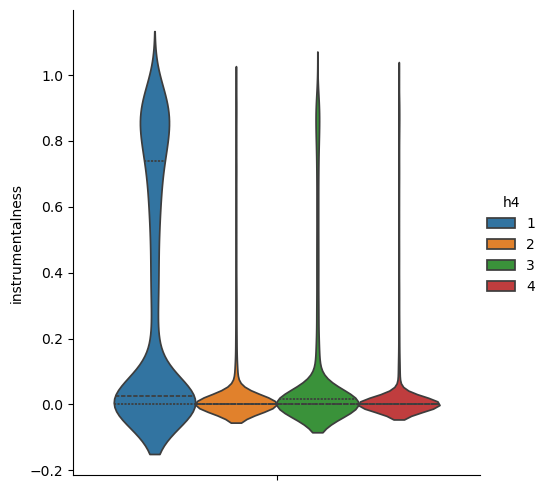

In [84]:
sns.catplot(data=spotify_copy, y='instrumentalness', hue='h4', kind='violin', inner='quartile')

plt.show()

`instrumentalness` shows the strongest cluster separation out of all features. Cluster 1 is characterized by extremely high instrumentalness values, indicating that it contains primarily instrumental tracks. In contrast, clusters 2, 3, and 4 all remain near zero, representing largely vocal songs. This suggests that one of the main distinctions captured by the four-cluster solution is whether a track is instrumental or vocal.

### Clustering Conclusions

Using PCA followed by Ward’s hierarchical clustering, a four-cluster solution emerged as the most interpretable structure in the data. The clusters were driven primarily by differences in continuous audio features rather than by categorical inputs. Cluster 1 was distinguished by extremely high `instrumentalness`, consistent mid-range `tempo`, and low `log_speechiness`, forming a group of tracks with audio characteristics often associated with EDM or instrumental music. Clusters 2–4 represented vocal tracks with varying degrees of `speechiness`, `energy`, `logit_acousticness`, `loudness`, and `tempo`, but showed less dramatic separation. A heatmap of cluster assignments against `playlist_genre`, `mode`, and `bin_year` (shown in my supporting document) confirmed that clusters were distributed across all genres, modes, and years indicating that the clustering captured underlying audio properties rather than categorical labels. Overall, the Ward four-cluster solution effectively summarized meaningful variation in the Spotify audio features and provided a clear, feature-based segmentation of the tracks.

## Fitting and Interpretation

To fit regression models, I first need to import the required functions from `statsmodels`.

In [85]:
import statsmodels.formula.api as smf

I want to find out if `h4` would make a good predictor. To do that, I will create a model with just `h4` as a predictor. If it contains statistically significant features, I will use it in my models.

In [86]:
h4_mod = smf.ols(formula='y ~ C(h4)', data=spotify_copy).fit()

In [87]:
h4_mod.pvalues

Intercept     1.555642e-176
C(h4)[T.2]     3.138291e-13
C(h4)[T.3]     4.793054e-03
C(h4)[T.4]     8.585272e-23
dtype: float64

In [88]:
h4_mod.rsquared

np.float64(0.004561928361528356)

Although the hierarchical clusters revealed meaningful differences in audio characteristics, the cluster labels showed almost no relationship with the response variable (R-squared = 0.004). As a result, the clusters will not be included as predictors in the regression models.

### Fit multiple models to predict the response of interest

The response variable I am trying to predict is `track_popularity`. However, due to the large density in the variable `track_popularity` at 0, I will instead use the logit transformation `y` that I previously created as the output instead, as this is an unbounded continuous variable.

I will now visualize once again the relationships between the continuous inputs and the output `y` to see what formulas should be tested for regression.

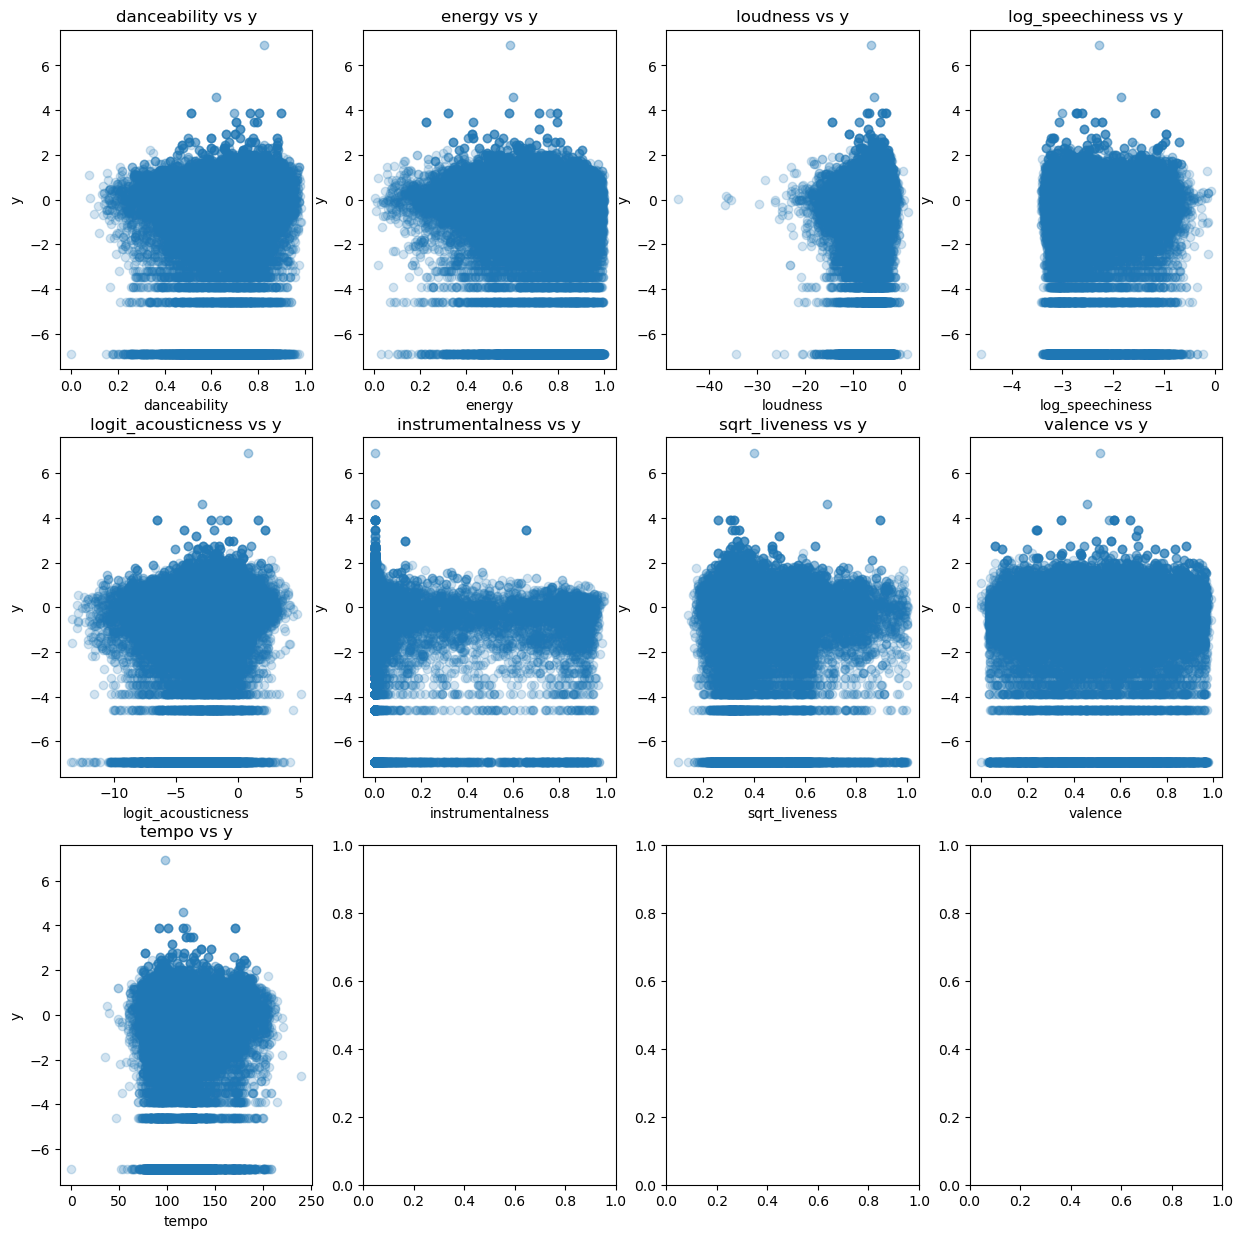

In [89]:
cont_vars = [
    'danceability', 'energy', 'loudness', 'log_speechiness',
    'logit_acousticness', 'instrumentalness', 'sqrt_liveness',
    'valence', 'tempo'
]

fig, axs = plt.subplots(3, 4, figsize=(15, 15))
axs = axs.flatten()

for i, var in enumerate(cont_vars):
    axs[i].scatter(spotify_copy[var], spotify_copy['y'], alpha=0.2)
    axs[i].set_xlabel(var)
    axs[i].set_ylabel('y')
    axs[i].set_title(f'{var} vs y')

plt.show()

In [90]:
formula_list = [
    # intercept only model
    'y ~ 1',
    # categorical inputs with additive features
    'y ~ playlist_genre + mode + key + release_month + bin_year',
    # continuous inputs with linear additive features
    'y ~ danceability + energy + loudness + log_speechiness + logit_acousticness + instrumentalness + sqrt_liveness + valence + tempo + duration_ms',
    # all inputs with linear additive features
    'y ~ playlist_genre + mode + key + release_month + bin_year + danceability + energy + loudness + log_speechiness + logit_acousticness + instrumentalness + sqrt_liveness + valence + tempo + duration_ms',
    # continuous inputs with linear main effect and pair-wise interactions
    'y ~ (danceability + energy + loudness + log_speechiness + logit_acousticness + instrumentalness + sqrt_liveness + valence + tempo + duration_ms) ** 2',
    # interact the categorical inputs and the continuous inputs
    'y ~ (playlist_genre + mode + key + release_month + bin_year) * (danceability + energy + loudness + log_speechiness + logit_acousticness + instrumentalness + sqrt_liveness + valence + tempo + duration_ms)',
    # linear additive features and interaction between playlist_genre, energy, and loudness as seen by relative correlation
    'y ~ (playlist_genre * loudness * energy)',
    # pairwise interactions among categorical and continuous inputs, with linear additive features
    'y ~ (playlist_genre + loudness + energy) ** 2 + mode + key + danceability + valence + tempo'
    ]

In [91]:
def fit_linear_model(mod_name, a_formula, data_df):
    # fit the model
    mod = smf.ols(formula=a_formula, data=data_df).fit()

    # summary statistics
    mod_fit_info = mod.conf_int().rename(columns={0: 'ci_lwr', 1: 'ci_upr'})
    mod_fit_info['mod_num'] = mod_name
    mod_fit_info['feature'] = mod_fit_info.index
    mod_fit_info['formula'] = a_formula
    mod_fit_info['estimate'] = mod.params
    mod_fit_info['estimate_se'] = mod.bse
    mod_fit_info['RMSE'] = np.sqrt((mod.resid ** 2).mean())
    mod_fit_info['pvalue'] = mod.pvalues
    mod_fit_info['pvalue < 0.05'] = mod.pvalues < 0.05
    mod_fit_info['num_coefs'] = len(mod.params)

    cols = ['mod_num', 'formula', 'feature', 'estimate', 'estimate_se', 'ci_lwr', 'ci_upr', 'RMSE', 'pvalue', 'pvalue < 0.05', 'num_coefs']
    mod_fit_info = mod_fit_info[cols]

    return mod_fit_info

In [92]:
fit_list = []

for m in range(len(formula_list)):
    fit_list.append(fit_linear_model(mod_name=m, a_formula=formula_list[m], data_df=spotify_copy))

I will now combine all fitted models into one DataFrame.

In [93]:
fit_res = pd.concat(fit_list, ignore_index=True)

In [94]:
fit_res.shape

(526, 11)

In [95]:
fit_res.to_csv('fit_res.csv', index=False)

### Analyze the Regression Coefficients

For each model, we can see the total number of coefficients that were estimated as shown below.

In [96]:
fit_res.groupby('mod_num')['num_coefs'].unique().sort_values().reset_index()

,mod_num,num_coefs
0,0,[1]
1,2,[11]
2,6,[24]
3,1,[30]
4,7,[34]
5,3,[40]
6,4,[56]
7,5,[330]


Out off all formula's tested, there are a total of 192 statistically significant coefficients out of 526. These significant features are visualized below in the coefficient plots.

In [97]:
fit_res.loc[ fit_res['pvalue < 0.05'] == True ].sort_values(by='estimate')

,mod_num,formula,feature,estimate,estimate_se,ci_lwr,ci_upr,RMSE,pvalue,pvalue < 0.05,num_coefs
480,6,y ~ (playlist_genre * loudness * energy),energy,-3.026023,0.487726,-3.981985,-2.070061,2.146158,5.559237e-10,True,24
516,7,y ~ (playlist_genre + loudness + energy) ** 2 ...,energy,-2.484500,0.291773,-3.056386,-1.912615,2.143423,1.734275e-17,True,34
142,5,y ~ (playlist_genre + mode + key + release_mon...,playlist_genre[T.rap],-2.281159,0.604629,-3.466254,-1.096064,2.075262,1.616995e-04,True,330
84,4,y ~ (danceability + energy + loudness + log_sp...,energy,-2.260466,1.067937,-4.353663,-0.167269,2.126150,3.429583e-02,True,56
199,5,y ~ (playlist_genre + mode + key + release_mon...,playlist_genre[T.latin]:energy,-2.243852,0.411333,-3.050080,-1.437624,2.075262,4.931479e-08,True,330
...,...,...,...,...,...,...,...,...,...,...,...
98,4,y ~ (danceability + energy + loudness + log_sp...,danceability:sqrt_liveness,2.224472,0.629395,0.990834,3.458110,2.126150,4.094280e-04,True,56
83,4,y ~ (danceability + energy + loudness + log_sp...,danceability,2.229916,0.917831,0.430932,4.028900,2.126150,1.512305e-02,True,56
139,5,y ~ (playlist_genre + mode + key + release_mon...,playlist_genre[T.latin],2.478242,0.639159,1.225465,3.731018,2.075262,1.058138e-04,True,330
167,5,y ~ (playlist_genre + mode + key + release_mon...,bin_year[T.recent],2.537747,0.410295,1.733552,3.341941,2.075262,6.278679e-10,True,330


In [98]:
def my_coefplot(mod, figsize_use=(10, 5)):
    # exclude non-significant features
    sig_mod = mod[mod.pvalue < 0.05]

    fig, ax = plt.subplots(figsize=figsize_use)

    ax.errorbar(y=sig_mod.estimate.index,
                x=sig_mod.estimate,
                xerr= 2 * sig_mod.estimate_se,
                fmt='o', color='k', ecolor='k', elinewidth=2, ms=10)
    
    ax.axvline(x=0, linestyle='--', linewidth=3.5, color='grey')

    ax.set_xlabel('coefficient value')

    plt.show()

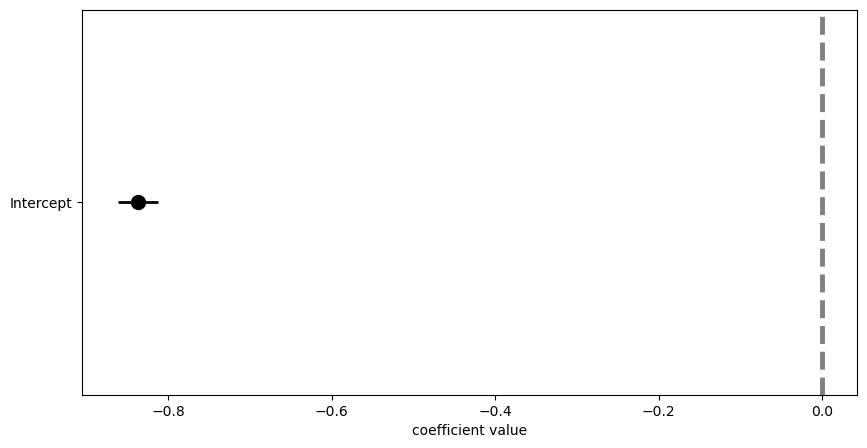

In [99]:
my_coefplot(mod=fit_list[0])

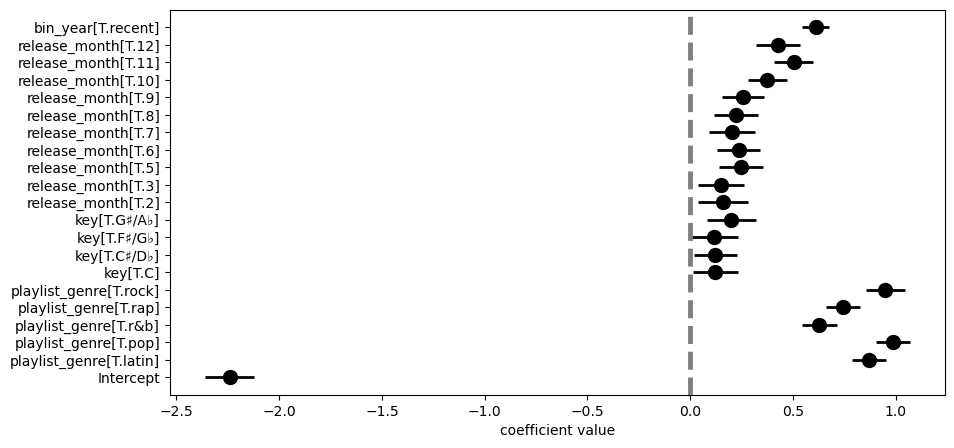

In [100]:
my_coefplot(mod=fit_list[1])

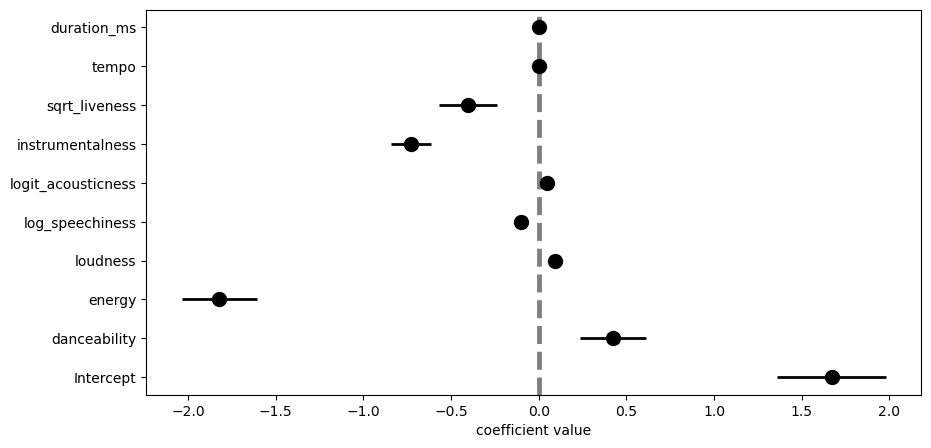

In [101]:
my_coefplot(mod=fit_list[2])

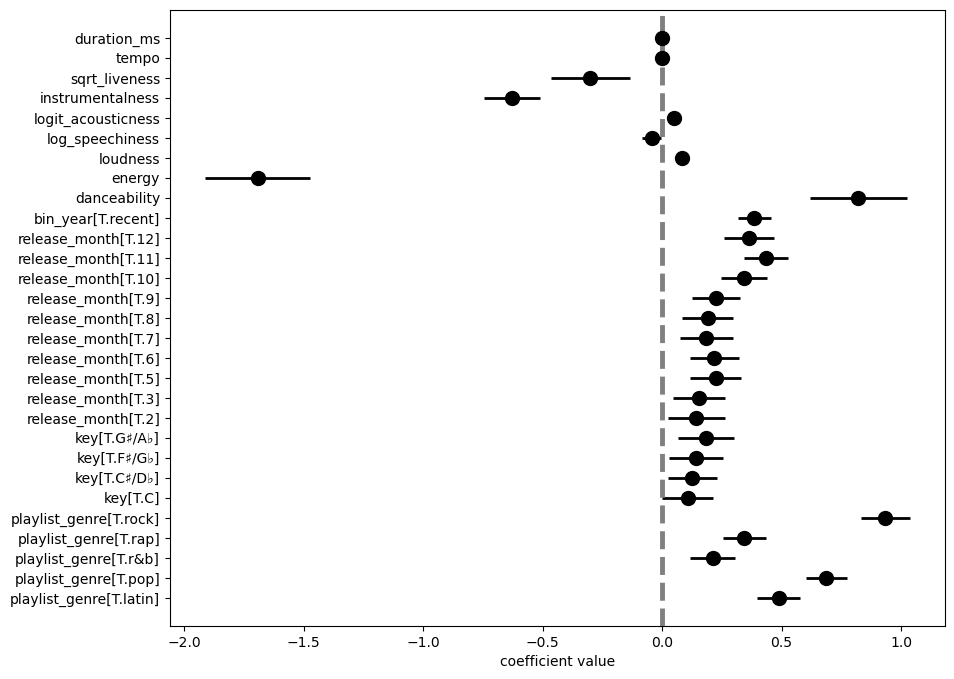

In [102]:
my_coefplot(mod=fit_list[3], figsize_use=(10,8))

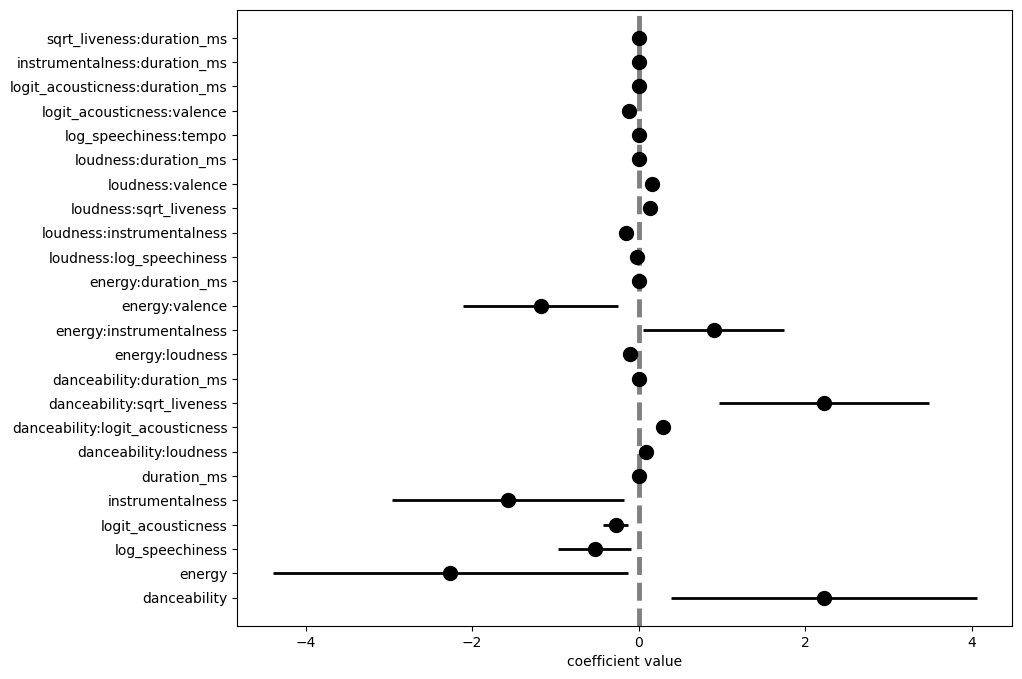

In [103]:
my_coefplot(mod=fit_list[4], figsize_use=(10,8))

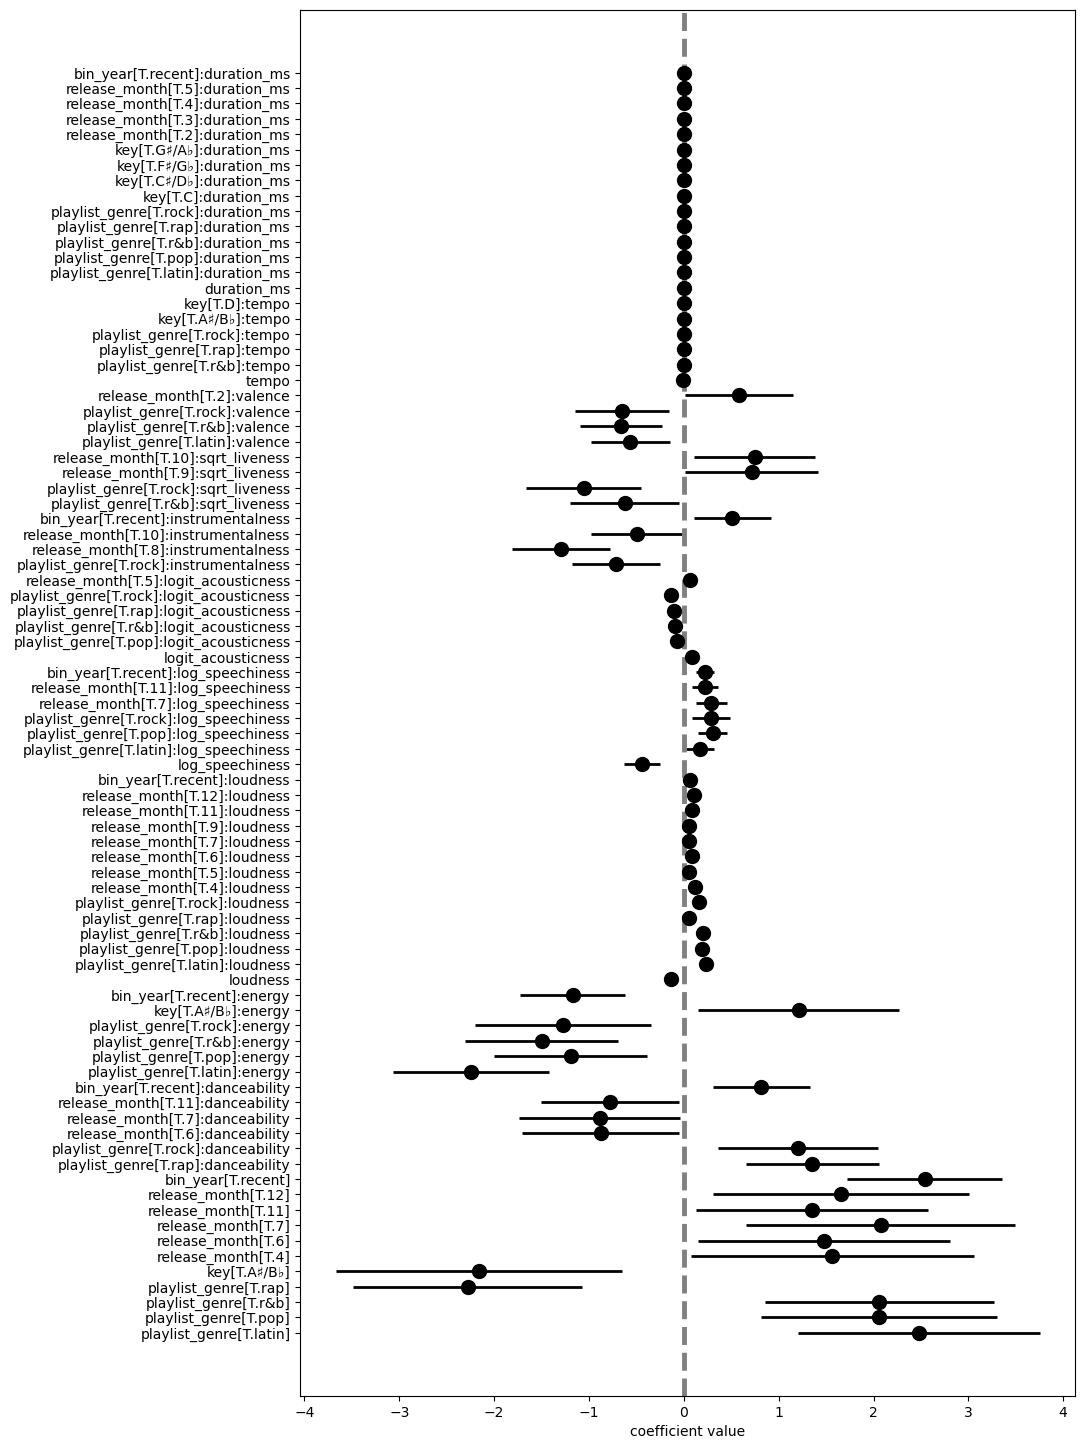

In [104]:
my_coefplot(mod=fit_list[5], figsize_use=(10,18))

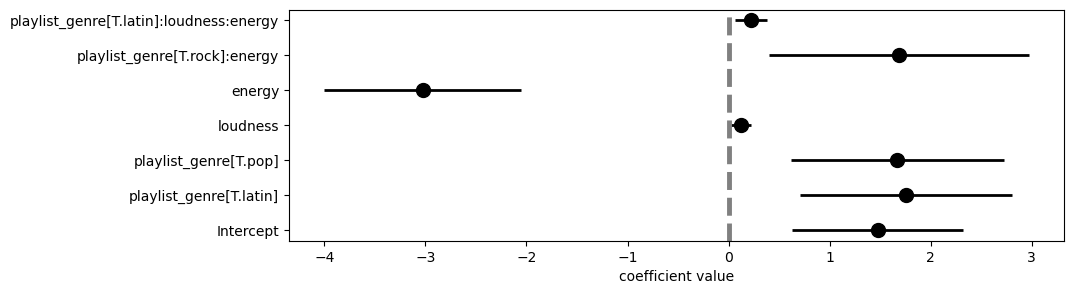

In [105]:
my_coefplot(mod=fit_list[6], figsize_use=(10,3))

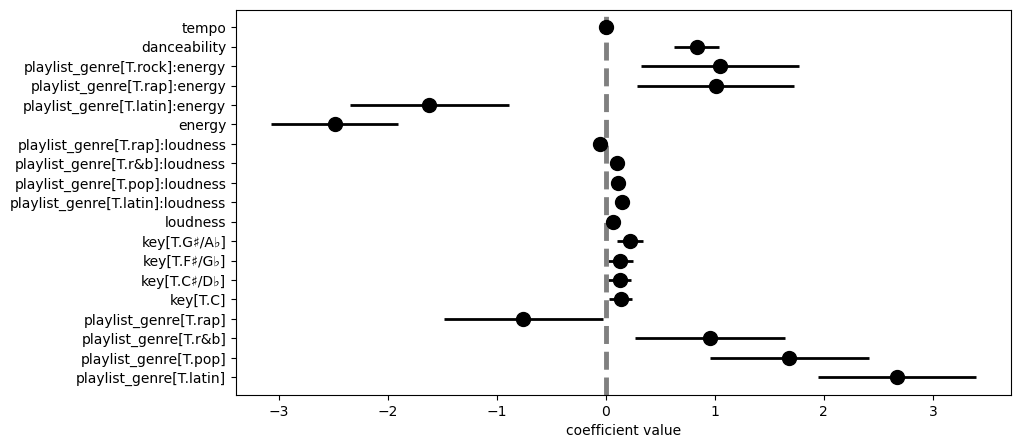

In [106]:
my_coefplot(mod=fit_list[7])

The coefficient plots demonstrate the many statistically significant features in predicting the output `y` for each model, but `energy` stood out to me as it appears to have a large impact on the models. It also looks like `playlist_genre` and `danceability` may also play a role in predicting popularity. Other input variables such as `loudness`, `log_speechiness`, `logit_acousticness`, and `duration_ms` are also significant, but they tend to have p-values VERY close to 0.05 which suggests that they might not be good predictors after all.

Of those 192 coefficients, 57 are negative as seen below and in the coefficient plots as well.

In [107]:
fit_res.loc[ fit_res['pvalue < 0.05'] & (fit_res['ci_upr'] < 0) ].sort_values(by='estimate', ascending=True)

,mod_num,formula,feature,estimate,estimate_se,ci_lwr,ci_upr,RMSE,pvalue,pvalue < 0.05,num_coefs
480,6,y ~ (playlist_genre * loudness * energy),energy,-3.026023e+00,4.877263e-01,-3.981985e+00,-2.070061e+00,2.146158,5.559237e-10,True,24
516,7,y ~ (playlist_genre + loudness + energy) ** 2 ...,energy,-2.484500e+00,2.917728e-01,-3.056386e+00,-1.912615e+00,2.143423,1.734275e-17,True,34
142,5,y ~ (playlist_genre + mode + key + release_mon...,playlist_genre[T.rap],-2.281159e+00,6.046285e-01,-3.466254e+00,-1.096064e+00,2.075262,1.616995e-04,True,330
84,4,y ~ (danceability + energy + loudness + log_sp...,energy,-2.260466e+00,1.067937e+00,-4.353663e+00,-1.672695e-01,2.126150,3.429583e-02,True,56
199,5,y ~ (playlist_genre + mode + key + release_mon...,playlist_genre[T.latin]:energy,-2.243852e+00,4.113327e-01,-3.050080e+00,-1.437624e+00,2.075262,4.931479e-08,True,330
1,1,y ~ playlist_genre + mode + key + release_mont...,Intercept,-2.240168e+00,6.010438e-02,-2.357975e+00,-2.122361e+00,2.157829,1.027896e-297,True,30
145,5,y ~ (playlist_genre + mode + key + release_mon...,key[T.A♯/B♭],-2.162703e+00,7.547838e-01,-3.642108e+00,-6.832981e-01,2.075262,4.168493e-03,True,330
33,2,y ~ danceability + energy + loudness + log_spe...,energy,-1.822219e+00,1.069768e-01,-2.031898e+00,-1.612541e+00,2.142539,8.867403e-65,True,11
73,3,y ~ playlist_genre + mode + key + release_mont...,energy,-1.692845e+00,1.098184e-01,-1.908093e+00,-1.477597e+00,2.116704,2.016138e-53,True,40
517,7,y ~ (playlist_genre + loudness + energy) ** 2 ...,playlist_genre[T.latin]:energy,-1.617782e+00,3.635170e-01,-2.330289e+00,-9.052747e-01,2.143423,8.601356e-06,True,34


In [108]:
fit_res.loc[ fit_res['pvalue < 0.05'] & (fit_res['estimate'] > 0) ].sort_values(by='estimate', ascending=False)

,mod_num,formula,feature,estimate,estimate_se,ci_lwr,ci_upr,RMSE,pvalue,pvalue < 0.05,num_coefs
493,7,y ~ (playlist_genre + loudness + energy) ** 2 ...,playlist_genre[T.latin],2.667424e+00,3.622687e-01,1.957364e+00,3.377484e+00,2.143423,1.839696e-13,True,34
167,5,y ~ (playlist_genre + mode + key + release_mon...,bin_year[T.recent],2.537747e+00,4.102953e-01,1.733552e+00,3.341941e+00,2.075262,6.278679e-10,True,330
139,5,y ~ (playlist_genre + mode + key + release_mon...,playlist_genre[T.latin],2.478242e+00,6.391593e-01,1.225465e+00,3.731018e+00,2.075262,1.058138e-04,True,330
83,4,y ~ (danceability + energy + loudness + log_sp...,danceability,2.229916e+00,9.178314e-01,4.309322e-01,4.028900e+00,2.126150,1.512305e-02,True,56
98,4,y ~ (danceability + energy + loudness + log_sp...,danceability:sqrt_liveness,2.224472e+00,6.293951e-01,9.908338e-01,3.458110e+00,2.126150,4.094280e-04,True,56
...,...,...,...,...,...,...,...,...,...,...,...
455,5,y ~ (playlist_genre + mode + key + release_mon...,key[T.G♯/A♭]:duration_ms,2.363047e-06,1.026452e-06,3.511623e-07,4.374932e-06,2.075262,2.133306e-02,True,330
456,5,y ~ (playlist_genre + mode + key + release_mon...,release_month[T.2]:duration_ms,2.146890e-06,1.019135e-06,1.493466e-07,4.144433e-06,2.075262,3.516171e-02,True,330
441,5,y ~ (playlist_genre + mode + key + release_mon...,playlist_genre[T.r&b]:duration_ms,1.849327e-06,7.076766e-07,4.622537e-07,3.236400e-06,2.075262,8.973102e-03,True,330
448,5,y ~ (playlist_genre + mode + key + release_mon...,key[T.C♯/D♭]:duration_ms,1.778315e-06,8.985562e-07,1.711005e-08,3.539519e-06,2.075262,4.781558e-02,True,330


The 2 coefficients that contain the overall highest magnitude in all models are `energy` in model 6 and `playlist_genre`, specifically `latin`, in model 7. These are shown below.

In [109]:
fit_res['abs_estimate'] = np.abs(fit_res.estimate)

In [110]:
fit_res.loc[ fit_res['pvalue < 0.05'] == True, ['mod_num', 'formula', 'feature', 'abs_estimate'] ].sort_values(by='abs_estimate', ascending=False).head(2)

,mod_num,formula,feature,abs_estimate
480,6,y ~ (playlist_genre * loudness * energy),energy,3.026023
493,7,y ~ (playlist_genre + loudness + energy) ** 2 ...,playlist_genre[T.latin],2.667424


The two coefficients with the highest magnitude in *each* model is shown below.

In [111]:
np.abs(fit_list[1].loc[ fit_list[1].pvalue < 0.05, 'estimate' ]).sort_values(ascending=False).head(2)

Intercept                2.240168
playlist_genre[T.pop]    0.985323
Name: estimate, dtype: float64

In [112]:
np.abs(fit_list[2].loc[ fit_list[2].pvalue < 0.05, 'estimate' ]).sort_values(ascending=False).head(2)

energy       1.822219
Intercept    1.669544
Name: estimate, dtype: float64

In [113]:
np.abs(fit_list[3].loc[ fit_list[3].pvalue < 0.05, 'estimate' ]).sort_values(ascending=False).head(2)

energy                    1.692845
playlist_genre[T.rock]    0.934853
Name: estimate, dtype: float64

In [114]:
np.abs(fit_list[4].loc[ fit_list[4].pvalue < 0.05, 'estimate' ]).sort_values(ascending=False).head(2)

energy          2.260466
danceability    2.229916
Name: estimate, dtype: float64

In [115]:
np.abs(fit_list[5].loc[ fit_list[5].pvalue < 0.05, 'estimate' ]).sort_values(ascending=False).head(2)

bin_year[T.recent]         2.537747
playlist_genre[T.latin]    2.478242
Name: estimate, dtype: float64

In [116]:
np.abs(fit_list[6].loc[ fit_list[6].pvalue < 0.05, 'estimate' ]).sort_values(ascending=False).head(2)

energy                     3.026023
playlist_genre[T.latin]    1.756411
Name: estimate, dtype: float64

In [117]:
np.abs(fit_list[7].loc[ fit_list[7].pvalue < 0.05, 'estimate' ]).sort_values(ascending=False).head(2)

playlist_genre[T.latin]    2.667424
energy                     2.484500
Name: estimate, dtype: float64

### Performance on the Training Set

For each model, I will show the predicted vs observed figure for the training set, and the R-squared and RMSE on the training set.

I will begin by pulling the output column `y` from `spotify_copy` and creating an output DataFrame.  I will then add my predictions for each function to `output_df`.

In [118]:
output_df = pd.DataFrame(spotify_copy.y)

In [119]:
for m, formula in enumerate(formula_list):
    mod = smf.ols(formula=formula, data=spotify_copy).fit()
    output_df[f'y_pred_{m}'] = mod.predict(spotify_copy)
    output_df[f'RMSE_{m}'] = np.sqrt((mod.resid ** 2).mean())
    output_df[f'rsquared_{m}'] = mod.rsquared
    output_df[f'residuals_{m}'] = mod.resid

In [120]:
for m, formula in enumerate(formula_list):
    mod = smf.ols(formula=formula, data=spotify_copy).fit()
    output_df[f'y_pred_{m}'] = mod.predict(spotify_copy)
    output_df[f'RMSE_{m}'] = np.sqrt((mod.resid ** 2).mean())
    output_df[f'rsquared_{m}'] = mod.rsquared
    output_df[f'residuals_{m}'] = mod.resid

#### Show the predicted vs observed figure for the training set

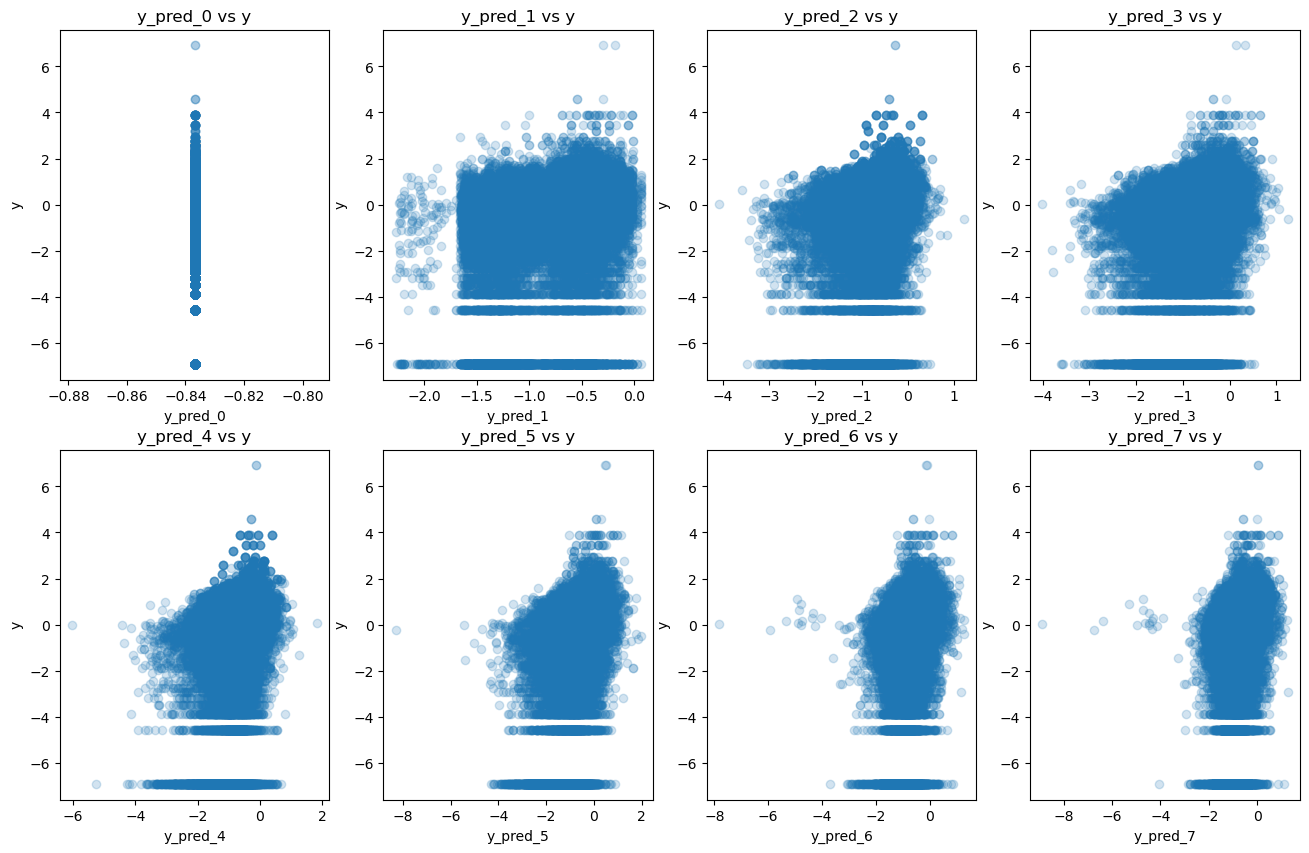

In [121]:
cont_vars = [
    'y_pred_0', 'y_pred_1', 'y_pred_2', 'y_pred_3', 'y_pred_4', 'y_pred_5', 'y_pred_6', 'y_pred_7'
]

fig, axs = plt.subplots(2, 4, figsize=(16, 10))
axs = axs.flatten()

for i, var in enumerate(cont_vars):
    axs[i].scatter(output_df[var], output_df['y'], alpha=0.2)
    axs[i].set_xlabel(var)
    axs[i].set_ylabel('y')
    axs[i].set_title(f'{var} vs y')

plt.show()

#### Model with the best performance on the training set

According to the RMSE, model 5 is the best model, which has an RMSE of 2.076.

In [122]:
output_df.T.loc[ output_df.T.index.str.contains('RMSE'), 0 ].sort_values(ascending=True)

RMSE_5    2.075262
RMSE_3    2.116704
RMSE_4    2.126150
RMSE_2    2.142539
RMSE_7    2.143423
RMSE_6    2.146158
RMSE_1    2.157829
RMSE_0    2.202296
Name: 0, dtype: float64

Model 5 also has the highest R-squared value, though it is a very weak R-squared at only 0.112, though this is still higher than the intercept-only model which has an R-squared of nearly 0.

In [123]:
output_df.T.loc[ output_df.T.index.str.contains('rsquared'), 0 ].sort_values(ascending=False)

rsquared_5    0.112037
rsquared_3    0.076220
rsquared_4    0.067956
rsquared_2    0.053532
rsquared_7    0.052751
rsquared_6    0.050332
rsquared_1    0.039975
rsquared_0    0.000000
Name: 0, dtype: float64

## Predictions

## 5. Models: Predictions

I will make predictions with two models:
1. The model with all inputs and linear additive features
2. The best model on the training set

In [124]:
mod_a = smf.ols(formula=formula_list[3], data=spotify_copy).fit()

In [125]:
mod_b = smf.ols(formula=formula_list[5], data=spotify_copy).fit()

First, I will create data sets to support visualizating the predictions.

For my first grid, I will identify the continuous input that is the most important based on statistically significant coefficients.

In [126]:
fit_res.loc[ fit_res.groupby('mod_num')['abs_estimate'].idxmax(), ['mod_num', 'abs_estimate', 'feature'] ].sort_index()

,mod_num,abs_estimate,feature
0,0,0.836897,Intercept
1,1,2.240168,Intercept
33,2,1.822219,energy
73,3,1.692845,energy
84,4,2.260466,energy
167,5,2.537747,bin_year[T.recent]
480,6,3.026023,energy
493,7,2.667424,playlist_genre[T.latin]


Based on the findings above, `energy` appears to be the most important statistically significant continuous coefficient, as it has the highest magnitude in 3 of the 8 models.

### Visualization Grid 1

For my first visualization grid, I will apply `np.linspace()` with 101 unique values between the minimum and maximum value in the continuous variable `energy` and use the central values (mean and median) to the remaining continuous variables. The categorical variables will also be used, but they will only use the most frequent category.

I chose to use different values for `energy` as I feel that this is the most influential continuous variable in the data.

In [127]:
input_grid_a = pd.DataFrame([

    (genre, mode, key, month, year, dance, energy, loud, speech, acoustic, instr, live, val, tempo, ms) 
    
    # most frequent categorical inputs
    for genre in spotify_copy['playlist_genre'].mode()
    for mode in spotify_copy['mode'].mode()
    for key in spotify_copy['key'].mode()
    for month in spotify_copy['release_month'].mode()
    for year in spotify_copy['bin_year'].mode()

    # continuous variables
    for dance in [spotify_copy.danceability.mean()]
    for energy in np.linspace(spotify_copy.energy.min(), spotify_copy.energy.max(), num=101)
    for loud in [spotify_copy.loudness.mean()]
    for speech in [spotify_copy.log_speechiness.median()]
    for acoustic in [spotify_copy.logit_acousticness.median()]
    for instr in [spotify_copy.instrumentalness.median()]
    for live in [spotify_copy.sqrt_liveness.median()]
    for val in [spotify_copy.valence.mean()]
    for tempo in [spotify_copy.tempo.mean()]
    for ms in [spotify_copy.duration_ms.mean()]

                            ],
                            
                            columns=[
                                'playlist_genre', 'mode', 'key', 'release_month', 'bin_year', 'danceability', 'energy', 'loudness', 'log_speechiness', 'logit_acousticness', 'instrumentalness', 'sqrt_liveness', 'valence', 'tempo', 'duration_ms'
                                ])

In [128]:
input_grid_a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   playlist_genre      101 non-null    object 
 1   mode                101 non-null    object 
 2   key                 101 non-null    object 
 3   release_month       101 non-null    int64  
 4   bin_year            101 non-null    object 
 5   danceability        101 non-null    float64
 6   energy              101 non-null    float64
 7   loudness            101 non-null    float64
 8   log_speechiness     101 non-null    float64
 9   logit_acousticness  101 non-null    float64
 10  instrumentalness    101 non-null    float64
 11  sqrt_liveness       101 non-null    float64
 12  valence             101 non-null    float64
 13  tempo               101 non-null    float64
 14  duration_ms         101 non-null    float64
dtypes: float64(10), int64(1), object(4)
memory usage: 12.0+ K

In [129]:
input_grid_a.nunique()

playlist_genre          1
mode                    1
key                     1
release_month           1
bin_year                1
danceability            1
energy                101
loudness                1
log_speechiness         1
logit_acousticness      1
instrumentalness        1
sqrt_liveness           1
valence                 1
tempo                   1
duration_ms             1
dtype: int64

I will now create a hard copy of `input_grid00`.

In [130]:
dfviz_a = input_grid_a.copy()

**Predictions on `mod_00`:**

In [131]:
predictions_a = mod_a.get_prediction(dfviz_a)

In [132]:
pred_summary_a = predictions_a.summary_frame()

In [133]:
pred_summary_a

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,-0.026921,0.096285,-0.215644,0.161802,-4.182603,4.128760
1,-0.043847,0.095379,-0.230793,0.143100,-4.199448,4.111755
2,-0.060772,0.094477,-0.245950,0.124406,-4.216294,4.094750
3,-0.077698,0.093579,-0.261115,0.105720,-4.233142,4.077746
4,-0.094623,0.092685,-0.276289,0.087043,-4.249990,4.060744
...,...,...,...,...,...,...
96,-1.651768,0.059912,-1.769197,-1.534338,-5.804822,2.501287
97,-1.668693,0.060392,-1.787064,-1.550322,-5.821775,2.484388
98,-1.685619,0.060888,-1.804962,-1.566275,-5.838728,2.467491
99,-1.702544,0.061400,-1.822891,-1.582198,-5.855682,2.450594


In [134]:
sns.set_style('whitegrid')

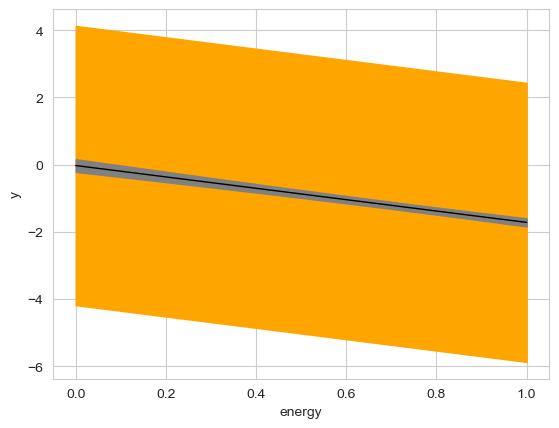

In [135]:
fig, ax = plt.subplots()

# prediction interval
ax.fill_between(dfviz_a.energy,
                pred_summary_a.obs_ci_lower, pred_summary_a.obs_ci_upper,
                facecolor='orange', edgecolor='orange')

# confidence interval
ax.fill_between(dfviz_a.energy,
                pred_summary_a.mean_ci_lower, pred_summary_a.mean_ci_upper,
                facecolor='grey', edgecolor='grey')

# average output line
ax.plot(dfviz_a.energy, pred_summary_a['mean'], color='k', linewidth=1)

# set labels
ax.set_xlabel('energy')
ax.set_ylabel('y')

plt.show()

As we can see, the plot of the input grid with respect to `energy` demonstrates a negative relationship showing that as `energy` increases, `y` decreases. This aligns with the regression results, where `energy` consistently had a negative coefficient estimate across all models.

The confidence interval (grey ribbon) is very close to the trend line, suggesting that the model estimates the mean response very accurately across the observed range of `energy`.

In contrast, the prediction interval (orange ribbon) is considerably wider. Although we are able to estimate the average effect of `energy` with high accuracy, there is much more uncertainty when predicting the popularity score of any new track data and we are not as confident that the data will be close to the trend line.

**Predictions on `mod_01`:**

In [136]:
predictions_b = mod_b.get_prediction(dfviz_a)

In [137]:
pred_summary_b = predictions_b.summary_frame()

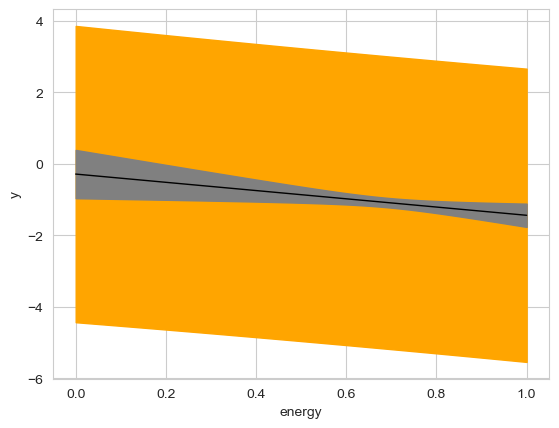

In [138]:
fig, ax = plt.subplots()

# prediction interval
ax.fill_between(dfviz_a.energy,
                pred_summary_b.obs_ci_lower, pred_summary_b.obs_ci_upper,
                facecolor='orange', edgecolor='orange')

# confidence interval
ax.fill_between(dfviz_a.energy,
                pred_summary_b.mean_ci_lower, pred_summary_b.mean_ci_upper,
                facecolor='grey', edgecolor='grey')

# average output line
ax.plot(dfviz_a.energy, pred_summary_b['mean'], color='k', linewidth=1)

# set labels
ax.set_xlabel('energy')
ax.set_ylabel('y')

plt.show()

The trend line and prediction intervals of `mod_01` appear to be similar to those of `mod_00`, but there are a few key differences. The slope in `mod_00` is slightly steeper, while `mod_01` shows a shallower negative relationship between `energy` and the `y`. In addition, the intercept for `mod_00` is closer to zero, whereas the intercept for `mod_01` lies slightly below zero. This reflects the differences in how each model accounts for other predictors.

The confidence band in `mod_01` is wider than in `mod_00`, suggesting greater uncertainty in the estimated mean response for a given value of energy. However, the prediction interval remains wide in both models, which is expected, as it incorporates the full variability of individual observations rather than just estimation uncertainty.

Overall, both models are good at explaining overall patterns, such as how `energy` relates to `y`, but predictions are much less certain. As a result, these models are better used for understanding trends rather than making accurate predictions.

### Visualization Grid 2

My second visualization grid will follow the same rules as the first, except I will now utilize two more of the most important inputs based on the statistically significant coefficients in my models.

I will still use `energy` with 101 unique values just as the first grid, but now I will include `danceability` and `playlist_genre`, as they are commonly found in the top 3 highest magnitudes in many of the models.

In [139]:
fit_res.loc[ fit_res['pvalue < 0.05'] == True ].\
    sort_values(['mod_num', 'abs_estimate'], ascending=[True, False]).\
    groupby('mod_num').head(3).loc[:, ['mod_num', 'abs_estimate', 'feature']]

,mod_num,abs_estimate,feature
0,0,0.836897,Intercept
1,1,2.240168,Intercept
3,1,0.985323,playlist_genre[T.pop]
6,1,0.948655,playlist_genre[T.rock]
33,2,1.822219,energy
31,2,1.669544,Intercept
37,2,0.727493,instrumentalness
73,3,1.692845,energy
47,3,0.934853,playlist_genre[T.rock]
72,3,0.820592,danceability


In [140]:
input_grid_b = pd.DataFrame([

    (genre, mode, key, month, year, dance, energy, loud, speech, acoustic, instr, live, val, tempo, ms) 
    
    # most frequent categorical inputs
    for genre in spotify_copy['playlist_genre'].unique()
    for mode in spotify_copy['mode'].mode()
    for key in spotify_copy['key'].mode()
    for month in spotify_copy['release_month'].mode()
    for year in spotify_copy['bin_year'].mode()

    # continuous variables
    for dance in np.linspace(spotify_copy.danceability.min(), spotify_copy.danceability.max(), num=5)
    for energy in np.linspace(spotify_copy.energy.min(), spotify_copy.energy.max(), num=101)
    for loud in [spotify_copy.loudness.mean()]
    for speech in [spotify_copy.log_speechiness.median()]
    for acoustic in [spotify_copy.logit_acousticness.median()]
    for instr in [spotify_copy.instrumentalness.median()]
    for live in [spotify_copy.sqrt_liveness.median()]
    for val in [spotify_copy.valence.mean()]
    for tempo in [spotify_copy.tempo.mean()]
    for ms in [spotify_copy.duration_ms.mean()]

                            ],
                            
                            columns=[
                                'playlist_genre', 'mode', 'key', 'release_month', 'bin_year', 'danceability', 'energy', 'loudness', 'log_speechiness', 'logit_acousticness', 'instrumentalness', 'sqrt_liveness', 'valence', 'tempo', 'duration_ms'
                                ])

In [141]:
input_grid_b.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3030 entries, 0 to 3029
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   playlist_genre      3030 non-null   object 
 1   mode                3030 non-null   object 
 2   key                 3030 non-null   object 
 3   release_month       3030 non-null   int64  
 4   bin_year            3030 non-null   object 
 5   danceability        3030 non-null   float64
 6   energy              3030 non-null   float64
 7   loudness            3030 non-null   float64
 8   log_speechiness     3030 non-null   float64
 9   logit_acousticness  3030 non-null   float64
 10  instrumentalness    3030 non-null   float64
 11  sqrt_liveness       3030 non-null   float64
 12  valence             3030 non-null   float64
 13  tempo               3030 non-null   float64
 14  duration_ms         3030 non-null   float64
dtypes: float64(10), int64(1), object(4)
memory usage: 355.2

In [142]:
input_grid_b.nunique()

playlist_genre          6
mode                    1
key                     1
release_month           1
bin_year                1
danceability            5
energy                101
loudness                1
log_speechiness         1
logit_acousticness      1
instrumentalness        1
sqrt_liveness           1
valence                 1
tempo                   1
duration_ms             1
dtype: int64

I will once again create a hard copy of the input grid and this time assign it to `dfviz01` and add a new column for predictions.

In [143]:
dfviz_b = input_grid_b.copy()

In [144]:
dfviz_b['pred_a'] = mod_a.predict(input_grid_b)

In [145]:
dfviz_b['pred_b'] = mod_b.predict(input_grid_b)

In [146]:
dfviz_b

,playlist_genre,mode,key,release_month,bin_year,danceability,energy,loudness,log_speechiness,logit_acousticness,instrumentalness,sqrt_liveness,valence,tempo,duration_ms,pred_a,pred_b
0,pop,major,C♯/D♭,1,recent,0.000,0.000175,-6.72766,-2.621414,-2.432874,0.000016,0.370135,0.511883,120.92709,225873.606742,0.123199,0.053293
1,pop,major,C♯/D♭,1,recent,0.000,0.010173,-6.72766,-2.621414,-2.432874,0.000016,0.370135,0.511883,120.92709,225873.606742,0.106274,0.029841
2,pop,major,C♯/D♭,1,recent,0.000,0.020172,-6.72766,-2.621414,-2.432874,0.000016,0.370135,0.511883,120.92709,225873.606742,0.089348,0.006389
3,pop,major,C♯/D♭,1,recent,0.000,0.030170,-6.72766,-2.621414,-2.432874,0.000016,0.370135,0.511883,120.92709,225873.606742,0.072423,-0.017063
4,pop,major,C♯/D♭,1,recent,0.000,0.040168,-6.72766,-2.621414,-2.432874,0.000016,0.370135,0.511883,120.92709,225873.606742,0.055497,-0.040516
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3025,edm,major,C♯/D♭,1,recent,0.983,0.960007,-6.72766,-2.621414,-2.432874,0.000016,0.370135,0.511883,120.92709,225873.606742,-1.382720,-1.126781
3026,edm,major,C♯/D♭,1,recent,0.983,0.970005,-6.72766,-2.621414,-2.432874,0.000016,0.370135,0.511883,120.92709,225873.606742,-1.399646,-1.138311
3027,edm,major,C♯/D♭,1,recent,0.983,0.980004,-6.72766,-2.621414,-2.432874,0.000016,0.370135,0.511883,120.92709,225873.606742,-1.416571,-1.149841
3028,edm,major,C♯/D♭,1,recent,0.983,0.990002,-6.72766,-2.621414,-2.432874,0.000016,0.370135,0.511883,120.92709,225873.606742,-1.433497,-1.161371


**Predictions on `mod_00`:**

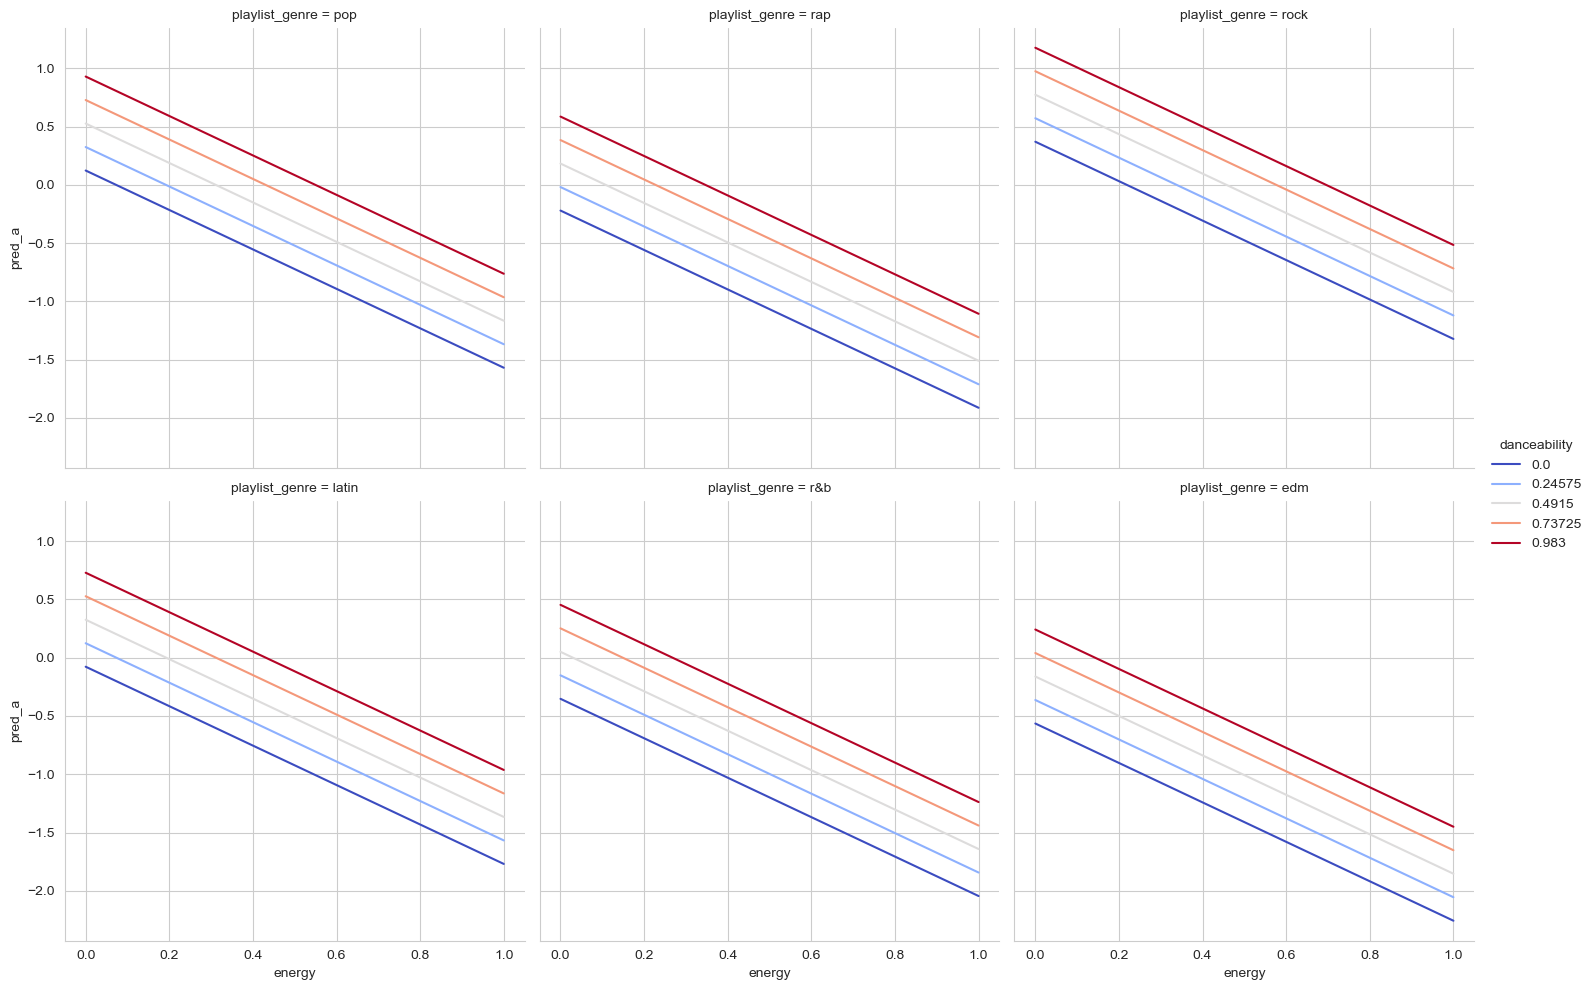

In [147]:
sns.relplot(data=dfviz_b, x='energy', y='pred_a', kind='line',
            hue='danceability', col='playlist_genre', col_wrap=3,
            palette='coolwarm',
            estimator=None, units='danceability')

plt.show()

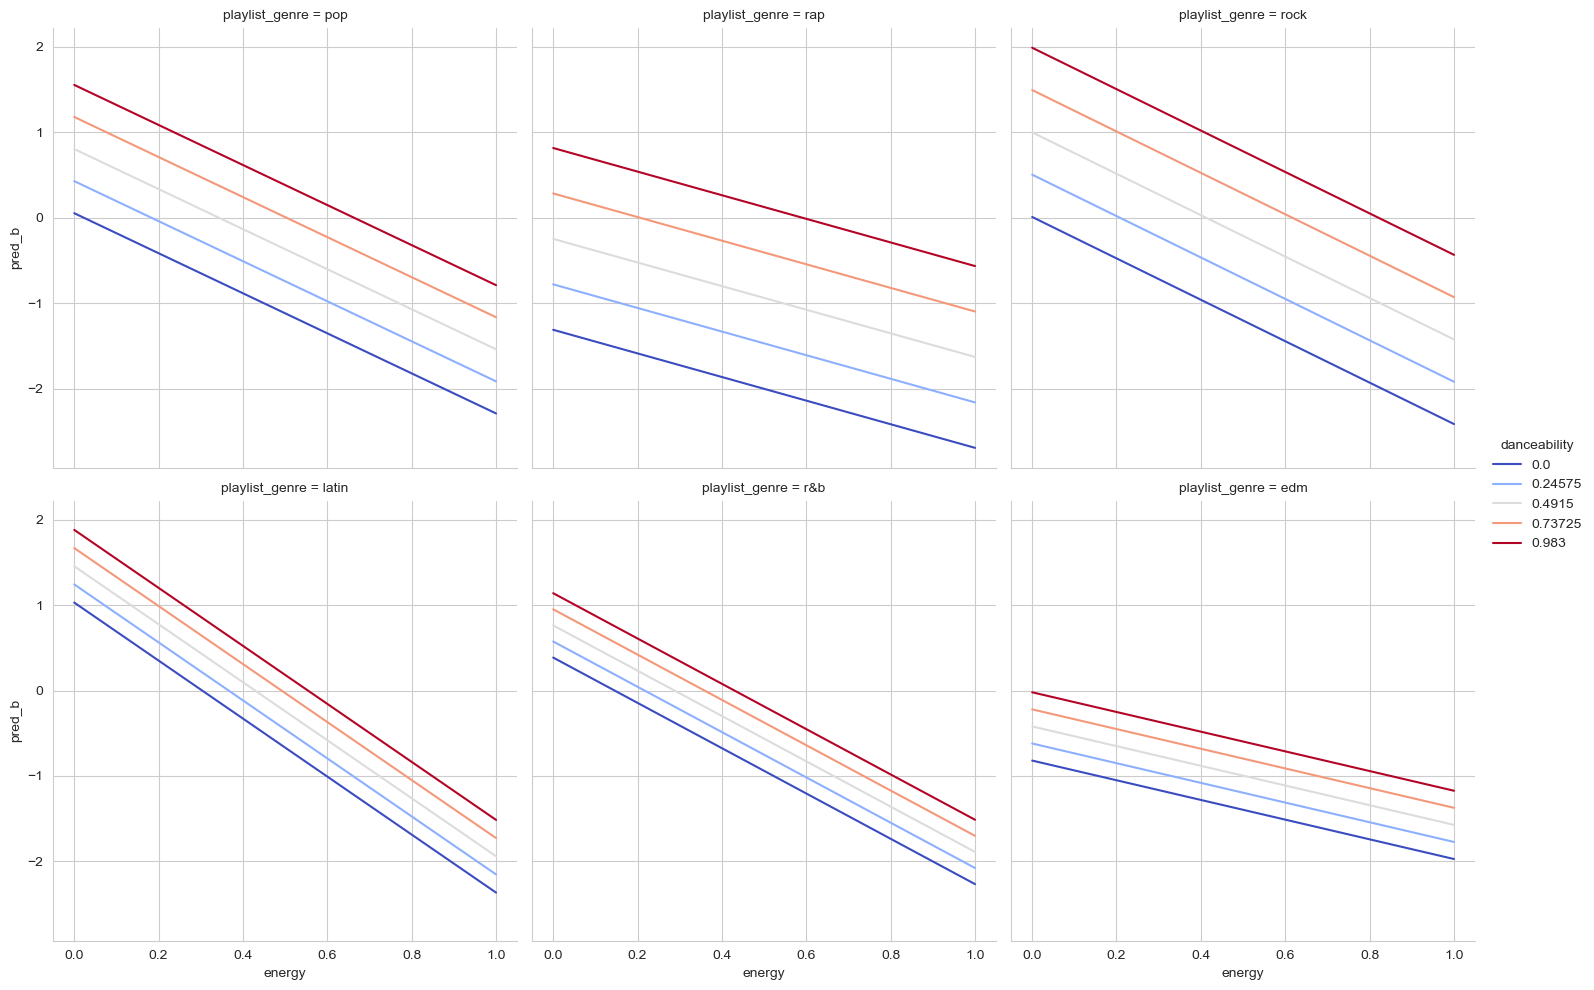

In [148]:
sns.relplot(data=dfviz_b, x='energy', y='pred_b', kind='line',
            hue='danceability', col='playlist_genre', col_wrap=3,
            palette='coolwarm',
            estimator=None, units='danceability')

plt.show()

On both models, higher danceability shifts the prediction upward. In `mod_00`, the `energy` slope is the same across genres, so `playlist_genre` does not change the slope. In `mod_01`, which includes interactions, `playlist_genre` modifies the relationship with `energy`, so each genre has a different slope.

## Performance and Validation

Here, I will focus on identifying the model that will perform the BEST on NEW data.  I will use cross-validation to calculate a more reliable estimate of the model performance.

I will use 3 formulas from my `formula_list`:
* The best model on the training set
* A simple model with few features
* A model with medium to high complexity

I will start by identifying the models I will use below.

Since I am using 5-fold cross-validation with regression, I need to import `KFold` from scikit-learn.

In [149]:
from sklearn.model_selection import KFold

In [150]:
kf = KFold(n_splits=5, shuffle=True, random_state=101)

### Execute Cross-Validation

I will now define a function that will fit and assess multiple linear regression models, as well as perform the 5-fold cross-validation. But first, I need to identify the names of the input variables as well as the name of the output variable.

In [151]:
input_names = spotify_copy.loc[ :,
    ['playlist_genre',
    'danceability',
    'energy',
    'key',
    'loudness',
    'mode',
    'instrumentalness',
    'valence',
    'tempo',
    'duration_ms',
    'release_month',
    'log_speechiness',
    'sqrt_liveness',
    'bin_year',
    'logit_acousticness']   
].copy().columns.to_list()

In [152]:
output_name = 'y'

To calculate the R-squared for the training and testing sets, I need to import `r2_score` from sklearn.

In [153]:
from sklearn.metrics import r2_score

In [154]:
def train_and_test_linear_with_cv(mod_name, a_formula, data_df, x_names, y_name, cv, threshold=0.5):
    # separate the inputs and the output
    input_df = data_df.loc[ :, x_names ].copy()

    # initialize the performance metric storage lists
    train_res = []
    test_res = []

    # SPLIT the data and iterate over the folds
    for train_id, test_id in cv.split( input_df.to_numpy(), data_df[ y_name ].to_numpy() ):
        # subset the training and test splits within each fold
        train_data = data_df.iloc[ train_id, : ].copy()
        test_data = data_df.iloc[ test_id, : ].copy()

        # FIT the model on the TRAINING data within the current FOLD
        a_mod = smf.ols(formula=a_formula, data=train_data).fit()

        # PREDICT the TRAINING within each FOLD
        train_copy = train_data.copy()
        train_copy['pred'] = a_mod.predict( train_data )

        # PREDICT the TESTING within each fold
        test_copy = test_data.copy()
        test_copy['pred'] = a_mod.predict( test_data )

        # calculate the PERFORMANCE METRIC on the TRAINING SET within the FOLD
        train_res.append( r2_score(train_copy[y_name], train_copy['pred']) )

        # calculate the PERFORMANCE METRIC on the TESTING SET within the FOLD
        test_res.append( r2_score(test_copy[y_name], test_copy['pred']) )

    # book keeping to store the metrics
    train_df = pd.DataFrame({'rsquared': train_res})
    train_df['from_set'] = 'training'
    train_df['fold_id'] = train_df.index + 1

    test_df = pd.DataFrame({'rsquared': test_res})
    test_df['from_set'] = 'testing'
    test_df['fold_id'] = test_df.index + 1

    # combine the splits together
    res_df = pd.concat( [train_df, test_df], ignore_index=True )

    # add information about the model
    res_df['model_name'] = mod_name
    res_df['model_formula'] = a_formula
    res_df['num_coefs'] = len( a_mod.params )
    res_df['threshold'] = threshold

    return res_df

Best model on the training set:

In [155]:
train_and_test_linear_with_cv(5, a_formula=formula_list[5], data_df=spotify_copy, x_names=input_names, y_name=output_name, cv=kf)

,rsquared,from_set,fold_id,model_name,model_formula,num_coefs,threshold
0,0.112624,training,1,5,y ~ (playlist_genre + mode + key + release_mon...,330,0.5
1,0.115768,training,2,5,y ~ (playlist_genre + mode + key + release_mon...,330,0.5
2,0.111696,training,3,5,y ~ (playlist_genre + mode + key + release_mon...,330,0.5
3,0.116775,training,4,5,y ~ (playlist_genre + mode + key + release_mon...,330,0.5
4,0.115490,training,5,5,y ~ (playlist_genre + mode + key + release_mon...,330,0.5
5,0.097639,testing,1,5,y ~ (playlist_genre + mode + key + release_mon...,330,0.5
6,0.084328,testing,2,5,y ~ (playlist_genre + mode + key + release_mon...,330,0.5
7,0.102235,testing,3,5,y ~ (playlist_genre + mode + key + release_mon...,330,0.5
8,0.079532,testing,4,5,y ~ (playlist_genre + mode + key + release_mon...,330,0.5
9,0.085355,testing,5,5,y ~ (playlist_genre + mode + key + release_mon...,330,0.5


Simple model with few features:

In [156]:
train_and_test_linear_with_cv(6, a_formula=formula_list[6], data_df=spotify_copy, x_names=input_names, y_name=output_name, cv=kf)

,rsquared,from_set,fold_id,model_name,model_formula,num_coefs,threshold
0,0.050928,training,1,6,y ~ (playlist_genre * loudness * energy),24,0.5
1,0.050901,training,2,6,y ~ (playlist_genre * loudness * energy),24,0.5
2,0.049193,training,3,6,y ~ (playlist_genre * loudness * energy),24,0.5
3,0.050591,training,4,6,y ~ (playlist_genre * loudness * energy),24,0.5
4,0.050935,training,5,6,y ~ (playlist_genre * loudness * energy),24,0.5
5,0.046689,testing,1,6,y ~ (playlist_genre * loudness * energy),24,0.5
6,0.047178,testing,2,6,y ~ (playlist_genre * loudness * energy),24,0.5
7,0.053825,testing,3,6,y ~ (playlist_genre * loudness * energy),24,0.5
8,0.048642,testing,4,6,y ~ (playlist_genre * loudness * energy),24,0.5
9,0.047177,testing,5,6,y ~ (playlist_genre * loudness * energy),24,0.5


Large model with medium to high complexity:

In [157]:
train_and_test_linear_with_cv(4, a_formula=formula_list[4], data_df=spotify_copy, x_names=input_names, y_name=output_name, cv=kf)

,rsquared,from_set,fold_id,model_name,model_formula,num_coefs,threshold
0,0.068636,training,1,4,y ~ (danceability + energy + loudness + log_sp...,56,0.5
1,0.067937,training,2,4,y ~ (danceability + energy + loudness + log_sp...,56,0.5
2,0.065862,training,3,4,y ~ (danceability + energy + loudness + log_sp...,56,0.5
3,0.071165,training,4,4,y ~ (danceability + energy + loudness + log_sp...,56,0.5
4,0.068272,training,5,4,y ~ (danceability + energy + loudness + log_sp...,56,0.5
5,0.062857,testing,1,4,y ~ (danceability + energy + loudness + log_sp...,56,0.5
6,0.066102,testing,2,4,y ~ (danceability + energy + loudness + log_sp...,56,0.5
7,0.074422,testing,3,4,y ~ (danceability + energy + loudness + log_sp...,56,0.5
8,0.052489,testing,4,4,y ~ (danceability + energy + loudness + log_sp...,56,0.5
9,0.064631,testing,5,4,y ~ (danceability + energy + loudness + log_sp...,56,0.5


In [158]:
cv_formula_list = [formula_list[5], formula_list[6], formula_list[4]]

In [159]:
results_list = []

for m in range(len(cv_formula_list)):
    results_list.append(train_and_test_linear_with_cv(m, cv_formula_list[m], data_df=spotify_copy, x_names=input_names, y_name=output_name, cv=kf))

In [160]:
cv_results = pd.concat(results_list, ignore_index=True)

In [161]:
cv_results

,rsquared,from_set,fold_id,model_name,model_formula,num_coefs,threshold
0,0.112624,training,1,0,y ~ (playlist_genre + mode + key + release_mon...,330,0.5
1,0.115768,training,2,0,y ~ (playlist_genre + mode + key + release_mon...,330,0.5
2,0.111696,training,3,0,y ~ (playlist_genre + mode + key + release_mon...,330,0.5
3,0.116775,training,4,0,y ~ (playlist_genre + mode + key + release_mon...,330,0.5
4,0.115490,training,5,0,y ~ (playlist_genre + mode + key + release_mon...,330,0.5
5,0.097639,testing,1,0,y ~ (playlist_genre + mode + key + release_mon...,330,0.5
6,0.084328,testing,2,0,y ~ (playlist_genre + mode + key + release_mon...,330,0.5
7,0.102235,testing,3,0,y ~ (playlist_genre + mode + key + release_mon...,330,0.5
8,0.079532,testing,4,0,y ~ (playlist_genre + mode + key + release_mon...,330,0.5
9,0.085355,testing,5,0,y ~ (playlist_genre + mode + key + release_mon...,330,0.5


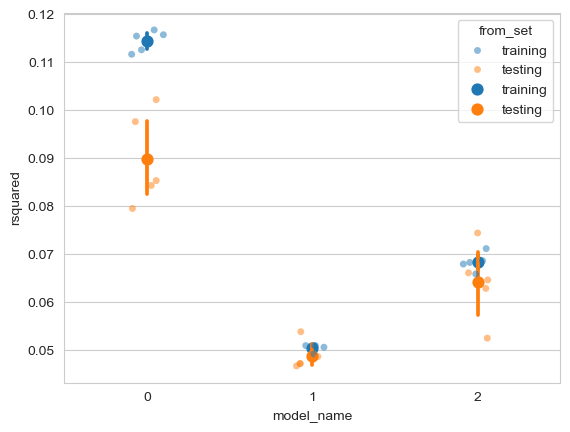

In [162]:
fig, ax = plt.subplots()

sns.stripplot(data=cv_results, x='model_name', y='rsquared', hue='from_set', alpha=0.5, ax=ax)

sns.pointplot(data=cv_results, x='model_name', y='rsquared', hue='from_set', linestyle='none', ax=ax)

plt.show()

The cross-validation results show that the model with the highest training R-squared also achieves the strongest performance on the testing folds. Although this model includes a large number of coefficients (over 300) and shows slight overfitting, its testing R² still exceeds the other models. This suggests that, despite its complexity, the model generalizes better than the simpler alternatives—though the overall predictive power remains limited.

## XGBoost

I used XGBoost as a bonus model because it can capture nonlinear relationships and interactions that linear regression cannot. Spotify audio features often behave in complex ways, and XGBoost is well-suited for learning these patterns with minimal preprocessing. It is fast, effective on tabular data, and provides stronger predictive performance than traditional linear models.

### Import XGBoost

In [163]:
import xgboost as xgb

In [164]:
X = spotify_copy[[
    'playlist_genre',
    'danceability',
    'energy',
    'key',
    'loudness',
    'mode',
    'instrumentalness',
    'valence',
    'tempo',
    'duration_ms',
    'release_month',
    'log_speechiness',
    'sqrt_liveness',
    'bin_year',
    'logit_acousticness'
]]

X = pd.get_dummies(X, drop_first=True)

In [165]:
y = spotify_copy['y']

### Create the train and test splits.

In [166]:
from sklearn.model_selection import train_test_split

In [167]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=121
)

### Fit an XGBoost Regressor Model

Do decide which parameters to use, I will create lists with different values and use `RandomizedSearchCV` to iterate across all parameters to find the best ones for making predictions.

In [168]:
param_grid = {
    'max_depth': [4, 5, 6, 7],
    'learning_rate': [0.03, 0.05, 0.1],
    'n_estimators': [300, 500, 700],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

In [169]:
from sklearn.model_selection import RandomizedSearchCV

rs = RandomizedSearchCV(
    estimator=xgb.XGBRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=20,
    scoring='r2',
    cv=3,
    random_state=121
)

rs.fit(X_train, y_train)
print(rs.best_params_)

{'subsample': 0.8, 'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


According to the randomized search, the best parameters are `subsample=0.8`, `n_estimators=500`, `max_dept=7`, `learning_rate=0.05`, and `colsample_bytree=1.0`.

Fit the XGBoost regressor model using `.XGBRegressor()`.

In [170]:
mod_xgb = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=1.0,
    random_state=121
)

In [171]:
mod_xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=1.0, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

### Model Accuracy on the Train Set

In [172]:
from sklearn.metrics import mean_squared_error

In [173]:
train_preds = mod_xgb.predict(X_train)

In [174]:
print(r2_score(y_train, train_preds))
print(mean_squared_error(y_train, train_preds))

0.6831626366095649
1.5349430231836678


In [175]:
test_preds = mod_xgb.predict(X_test)

In [176]:
print(r2_score(y_test, test_preds))
print(mean_squared_error(y_test, test_preds))

0.14386630779914256
4.171105686607589


As we can see by the R-squared values, XGBoost has overfitted the model. Because of this, convert my data into a DMatrix and implement early stopping.

In [177]:
from xgboost.callback import EarlyStopping

In [178]:
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

In [179]:
dparams = {
    'objective': 'reg:squarederror',
    'eta': 0.05,
    # I will use shallower trees to help prevent overfitting
    'max_depth': 3,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'eval_metric': 'rmse'
}

In [180]:
mod_xgb_2 = xgb.train(
    params=dparams,
    dtrain=dtrain,
    num_boost_round=500,
    evals=[(dtrain, 'train'), (dtest, 'eval')],
    early_stopping_rounds=50
)

[0]	train-rmse:2.19577	eval-rmse:2.20259
[1]	train-rmse:2.19049	eval-rmse:2.19818
[2]	train-rmse:2.18648	eval-rmse:2.19458
[3]	train-rmse:2.18169	eval-rmse:2.19029
[4]	train-rmse:2.17760	eval-rmse:2.18679
[5]	train-rmse:2.17325	eval-rmse:2.18347
[6]	train-rmse:2.16933	eval-rmse:2.17998
[7]	train-rmse:2.16530	eval-rmse:2.17623
[8]	train-rmse:2.16164	eval-rmse:2.17285
[9]	train-rmse:2.15851	eval-rmse:2.17012
[10]	train-rmse:2.15519	eval-rmse:2.16704
[11]	train-rmse:2.15197	eval-rmse:2.16438
[12]	train-rmse:2.14882	eval-rmse:2.16193
[13]	train-rmse:2.14636	eval-rmse:2.15965
[14]	train-rmse:2.14386	eval-rmse:2.15752
[15]	train-rmse:2.14134	eval-rmse:2.15572
[16]	train-rmse:2.13930	eval-rmse:2.15418
[17]	train-rmse:2.13677	eval-rmse:2.15230
[18]	train-rmse:2.13452	eval-rmse:2.15036
[19]	train-rmse:2.13256	eval-rmse:2.14884
[20]	train-rmse:2.13053	eval-rmse:2.14736
[21]	train-rmse:2.12854	eval-rmse:2.14574
[22]	train-rmse:2.12714	eval-rmse:2.14470
[23]	train-rmse:2.12578	eval-rmse:2.14363
[2

In [181]:
dtrain_preds = mod_xgb_2.predict(dtrain)

In [182]:
print(r2_score(y_train, dtrain_preds))
print(mean_squared_error(y_train, dtrain_preds))

0.18780544202745164
3.9347391257370288


In [183]:
dtest_preds = mod_xgb_2.predict(dtest)

In [184]:
print(r2_score(y_test, dtest_preds))
print(mean_squared_error(y_test, dtest_preds))

0.111017284308364
4.33114698615003


Visualize the importance of each feature.

In [185]:
from xgboost import plot_importance

<Figure size 640x480 with 0 Axes>

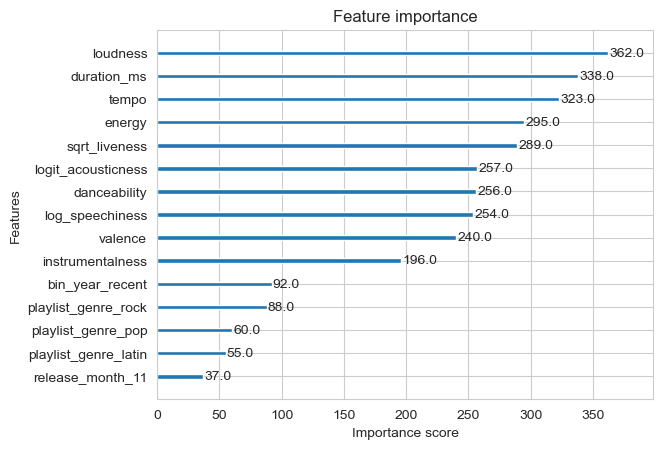

In [186]:
plt.figure()

plot_importance(mod_xgb_2, max_num_features=15)

plt.show()

XGBoost identifies continuous audio features as the primary drivers of popularity while the categorical variables contribute far less. This aligns with my EDA findings and cluster analysis. This pattern is consistent with the EDA and cluster results which showed that audio characteristics carry the most influence on the output `y`.

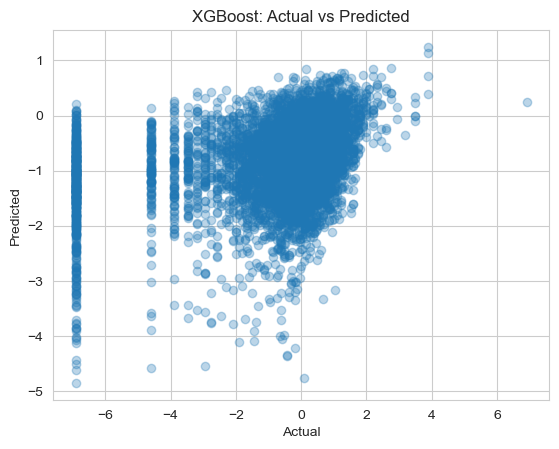

In [187]:
fig, ax = plt.subplots()

plt.scatter(y_test, dtest_preds, alpha=0.3)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("XGBoost: Actual vs Predicted")

plt.show()

The XGBoost model captures broad trends in the data but shows substantial scatter around the diagonal, indicating limited predictive accuracy. This is expected given the noisy nature of the popularity outcome: even with nonlinear modeling, audio features explain only a modest portion of the variation in `y`.

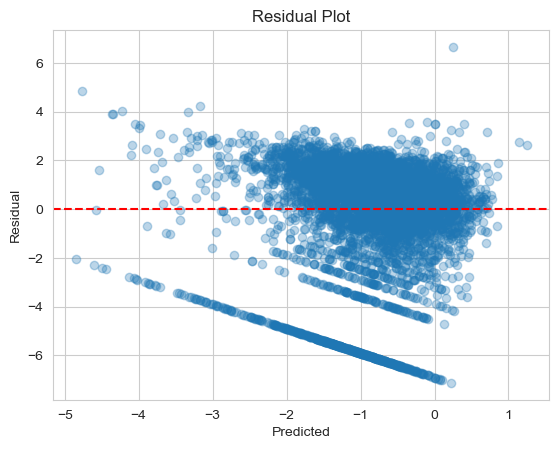

In [188]:
resid = y_test - dtest_preds

fig, ax = plt.subplots()

# scatter plot of dtest_preds vs residuals
plt.scatter(dtest_preds, resid, alpha=0.3)

# plot a line at 0 to represent residuals
plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

Residuals are centered around zero but show a wide spread across prediction values, confirming that the model has difficulty capturing the full complexity of popularity.

### Cross-Validation

In [189]:
xgb_cv = xgb.cv(
    params=dparams,
    dtrain=dtrain,
    num_boost_round=500,
    nfold=5,
    early_stopping_rounds=50,
    metrics='rmse',
    seed=121,
    verbose_eval=False
)

In [190]:
xgb_cv

,train-rmse-mean,train-rmse-std,test-rmse-mean,test-rmse-std
0,2.195611,0.009996,2.195652,0.039096
1,2.190225,0.010020,2.190588,0.039207
2,2.185715,0.009989,2.186307,0.039332
3,2.180881,0.009946,2.181634,0.039235
4,2.176742,0.009854,2.177757,0.039501
...,...,...,...,...
495,1.970531,0.007653,2.062813,0.036181
496,1.970332,0.007650,2.062804,0.036240
497,1.970163,0.007659,2.062823,0.036226
498,1.970003,0.007652,2.062824,0.036188


In [191]:
xgb_cv.shape[0]

500

Cross-validation did not trigger early stopping, indicating that validation RMSE continued to improve throughout all 500 boosting rounds. Therefore, the best iteration selected by XGBoost was the final round (500), which was used to train the final model.

I will now visualize my cross-validation results in a stripplot.

In [192]:
cv_long = xgb_cv.reset_index().\
    rename(columns={'index': 'iteration'}).\
        melt(id_vars='iteration',
             value_vars=['train-rmse-mean', 'test-rmse-mean'],
             var_name='from_set',
             value_name='rmse')

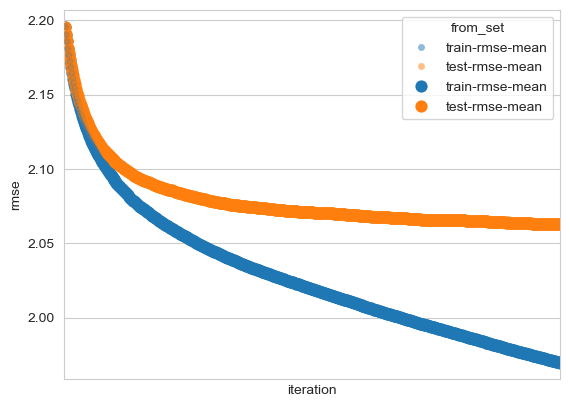

In [193]:
fig, ax = plt.subplots()

sns.stripplot(data=cv_long, x='iteration', y='rmse', hue='from_set', alpha=0.5, ax=ax)

sns.pointplot(data=cv_long, x='iteration', y='rmse', hue='from_set', linestyles='none', ax=ax)

ax.set_xticks([])

plt.show()

The CV curves show that both training and validation RMSE decrease and stabilize over time. The small gap between the curves indicates limited overfitting, and the model continued improving up to the full 500 rounds.

### Conclusion

The initial XGBoost model showed strong overfitting, with the train split showing an R-squared around 0.68, but the test split R-squared only 0.14. After applying regularization (reduced max_depth, subsampling, column sampling, and L2 penalty), the model generalized much better: the train R-squared dropped to 0.18 and the test R-squared was 0.11. Although the overall predictive power remains limited, this is expected given the noisy nature of popularity, and the regularized model provides a more reliable estimate of the explainable variation in the data.